# Extensive benchmarking for DD

#### Circuit : GHZ

#### Qubits  : Low {7, 8, 9, 10}, Medium: {17, 18, 19, 20}, Large: {27, 28, 29, 30}

#### Types
- Only opt 3 transpilation
- opt 3 + ASAP
- opt 3 + ALAP
- opt 3 + ASAP + DD(xx)
- opt 3 + ALAP + DD(xx)
- opt 3 + ASAP + DD(xpxm)
- opt 3 + ALAP + DD(xpxm)
- opt 3 + ASAP + DD(xy)
- opt 3 + ALAP + DD(xy)

#### Iterations : 3 


## Necessary Imports, Functions and Utils

In [1]:
import dill

from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, YGate
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
from qiskit_ibm_runtime import IBMBackend
from qiskit.visualization import timeline_drawer
from qiskit.transpiler import Target

In [2]:

def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


class BenchmarkOptions:
    def __init__(
        self, 
        backend_name: str = "ibm_fez", 
        opt_level: int = 3, 
        do_dd: bool = False,
        scheduling_method: str | None = None, 
        dd_pulse: str | None = None
    ):
        # Allow any backend 
        try:
            self.backend = QiskitRuntimeService().backend(backend_name)
        except Exception as e:
            print(f"Warning: Could not connect to backend '{backend_name}'. {e}")
            self.backend = None

        self.opt_level = opt_level
        self.do_dd = do_dd
        self.dd_pulse = dd_pulse
        self.scheduling_method = scheduling_method
        self.basis_gates = list(self.backend.target.operation_names)

        ## Default pulse sequence is xx
        if self.do_dd and self.dd_pulse is None:
            self.dd_pulse = 'xx'

        


def pm_for_backend(bknd, opt_level:int, seed:int, scheduling_method:str = "none", target:Target | None = None):
    ## Returns a normal (no dd) PassManager from generate_preset_pass_manager for given opt_level and backend(bknd) al
    
    if target is None:
        target = bknd.target
        
    ## for no scheduling case
    if scheduling_method == 'none':
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    
    ## for "alap" and "asap" cases
    else:
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=scheduling_method, target=target)
    
    return pm


def make_passmanager(benchmark_options:BenchmarkOptions):
    
    backend = benchmark_options.backend if benchmark_options.backend else QiskitRuntimeService().backend("ibm_fez")
    opt_level = benchmark_options.opt_level if benchmark_options.opt_level else 3
    scheduling_method = benchmark_options.scheduling_method if benchmark_options.scheduling_method else 'none'

    print(f"Transpilation options:\nbackend:{backend}\noptlevel:{opt_level}\nscheduling:{scheduling_method}\ndo_dd:{benchmark_options.do_dd}\ndd_pulse:{benchmark_options.dd_pulse}")

    ## Fix seed for reprodicubility
    pm_seed = 42069

    ## Include DD
    if benchmark_options.do_dd:
        return prepare_dd_pm(benchmark_options=benchmark_options)

    ## Defaults to no dd PM with opt_level = 3 and given scheduling_method
    else:
        return pm_for_backend(bknd=backend, opt_level=opt_level, seed=pm_seed, scheduling_method=scheduling_method)




def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler

def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(benchmark_options:BenchmarkOptions):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 

    # Default Sequence
    sequenece = [XGate(), XGate()]

    target = benchmark_options.backend.target

    seq = benchmark_options.dd_pulse

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    if seq.lower() == 'xy':
        from qiskit.transpiler import InstructionProperties

        sequenece = [XGate(), YGate(), XGate(), YGate()]

        y_gate_properties = {}

        for qubit in range(target.num_qubits):
            y_gate_properties.update(
                {
                    (qubit,): InstructionProperties(
                        duration=target["x"][(qubit,)].duration,
                        error=target["x"][(qubit,)].error,
                    )
                }
            )
        
        target.add_instruction(YGate(), y_gate_properties)

    


    ## Prepare a preset passmanager for backend optimization_level=3 and target (target is modified if seq = 'xy)
    pm = pm_for_backend(bknd=benchmark_options.backend, opt_level=3, seed=42069, target=target)

    try:
            
        if benchmark_options.scheduling_method:    
                if benchmark_options.scheduling_method == 'asap':
                    pm.scheduling.append(ASAPScheduleAnalysis(target=target))

                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
                
                elif benchmark_options.scheduling_method == 'alap':
                    pm.scheduling.append(ALAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    except:
        print(f"Error in sequence({seq}) or scheduling method({benchmark_options.scheduling_method})")

    return pm




def mega_transpiler(circuit:QuantumCircuit, dd_pm:StagedPassManager, benchmark_options:BenchmarkOptions) -> QuantumCircuit:
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    ## Final Translation to convert Y gates into basis equivalent gates
    if benchmark_options.do_dd is True:
        if benchmark_options.dd_pulse.lower() == 'xy':
            from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
            from qiskit.transpiler.passes import BasisTranslator
            

            basis_gates = benchmark_options.basis_gates
            

            return BasisTranslator(sel, basis_gates)(isa_dd_circuit)
        else:
            return isa_dd_circuit

    ## Normal case for xx dd and xpxm dd
    else:
        return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]




    


## Utils

In [3]:
# 2. Save Function (Generic for any object)
def save_object(obj, filename):
    try:
        with open(filename, 'wb') as f:
            dill.dump(obj, f)
        print(f"Object saved to '{filename}'")
    except Exception as e:
        print(f"Error saving object: {e}")

# 3. Load Function
def load_object(filename):
    try:
        with open(filename, 'rb') as f:
            obj = dill.load(f)
        print(f"Object loaded from '{filename}'")
        return obj
    except Exception as e:
        print(f"Error loading object: {e}")

## Prepare circuit

In [4]:
qubits = [7, 8, 9, 10, 17, 18, 19, 20, 27, 28, 29, 30]

circuit_dict = {}

for qubit in qubits:
    circuit_dict[qubit] = prepare_ghz(qubit)

circuit_dict

{7: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d4aff31d0>,
 8: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d203adc90>,
 9: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1edd0990>,
 10: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d4ae09210>,
 17: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1e8203d0>,
 18: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d20300490>,
 19: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d203e4d50>,
 20: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d2015a6d0>,
 27: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1e822990>,
 28: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1f5c8a90>,
 29: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1f825010>,
 30: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d4ae09090>}

## Backend

In [5]:
service = QiskitRuntimeService(name="qamp-2025-2")

fez = service.backend("ibm_fez")

management.get:WARNING:2025-12-11 19:18:14,339: Loading saved account: qamp-2025-2


In [6]:
type(fez)

qiskit_ibm_runtime.ibm_backend.IBMBackend

## Transpile Circuits

In [7]:

methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]


passmanagers_to_test = {}

options_dict = {}

for method in methods_list:
    
    options_dict[method] = BenchmarkOptions(scheduling_method=method)
    
    passmanagers_to_test[method] = make_passmanager(options_dict[method])



for dd_method in dd_methods_list:
    dd_method_split = dd_method.split("+")
    options_dict[dd_method] = BenchmarkOptions(scheduling_method=dd_method_split[0], do_dd = True, dd_pulse=dd_method_split[2])
    
    passmanagers_to_test[dd_method] = make_passmanager(options_dict[dd_method])



for dd_method in extra_dd_methods_list:
    dd_method_split = dd_method.split("+")
    options_dict[dd_method] = BenchmarkOptions(scheduling_method=dd_method_split[0], do_dd = True, dd_pulse=dd_method_split[2])
    
    passmanagers_to_test[dd_method] = make_passmanager(options_dict[dd_method])



management.get:WARNING:2025-12-11 19:18:19,455: Loading default saved account
management.get:WARNING:2025-12-11 19:18:25,550: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:none
do_dd:False
dd_pulse:None


management.get:WARNING:2025-12-11 19:18:33,462: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:asap
do_dd:False
dd_pulse:None


management.get:WARNING:2025-12-11 19:18:38,109: Loading default saved account


...

Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:alap
do_dd:True
dd_pulse:xpxm


management.get:WARNING:2025-12-11 19:19:01,710: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:asap
do_dd:True
dd_pulse:xpxm


management.get:WARNING:2025-12-11 19:19:08,149: Loading default saved account


Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:asap
do_dd:True
dd_pulse:xy
Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:alap
do_dd:True
dd_pulse:xy


In [8]:
passmanagers_to_test

{'none': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d1e347510>,
 'asap': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d1cc13010>,
 'alap': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d1cc01490>,
 'asap+dd+xx': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d1c5171d0>,
 'alap+dd+xx': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d17cdedd0>,
 'alap+dd+xpxm': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d17571110>,
 'asap+dd+xpxm': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d168f1790>,
 'asap+dd+xy': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d1672c7d0>,
 'alap+dd+xy': <qiskit.transpiler.passmanager.StagedPassManager at 0x756d161bd610>}

## Passmanager diagrams

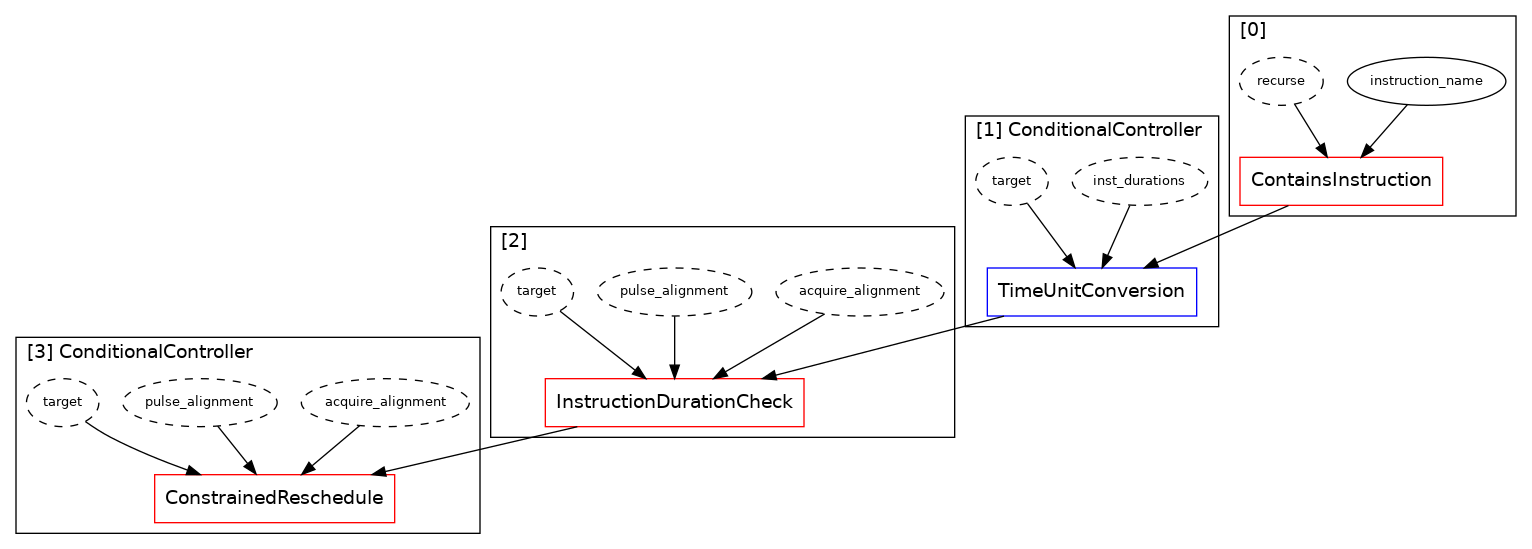

In [9]:
passmanagers_to_test['none'].scheduling.draw()

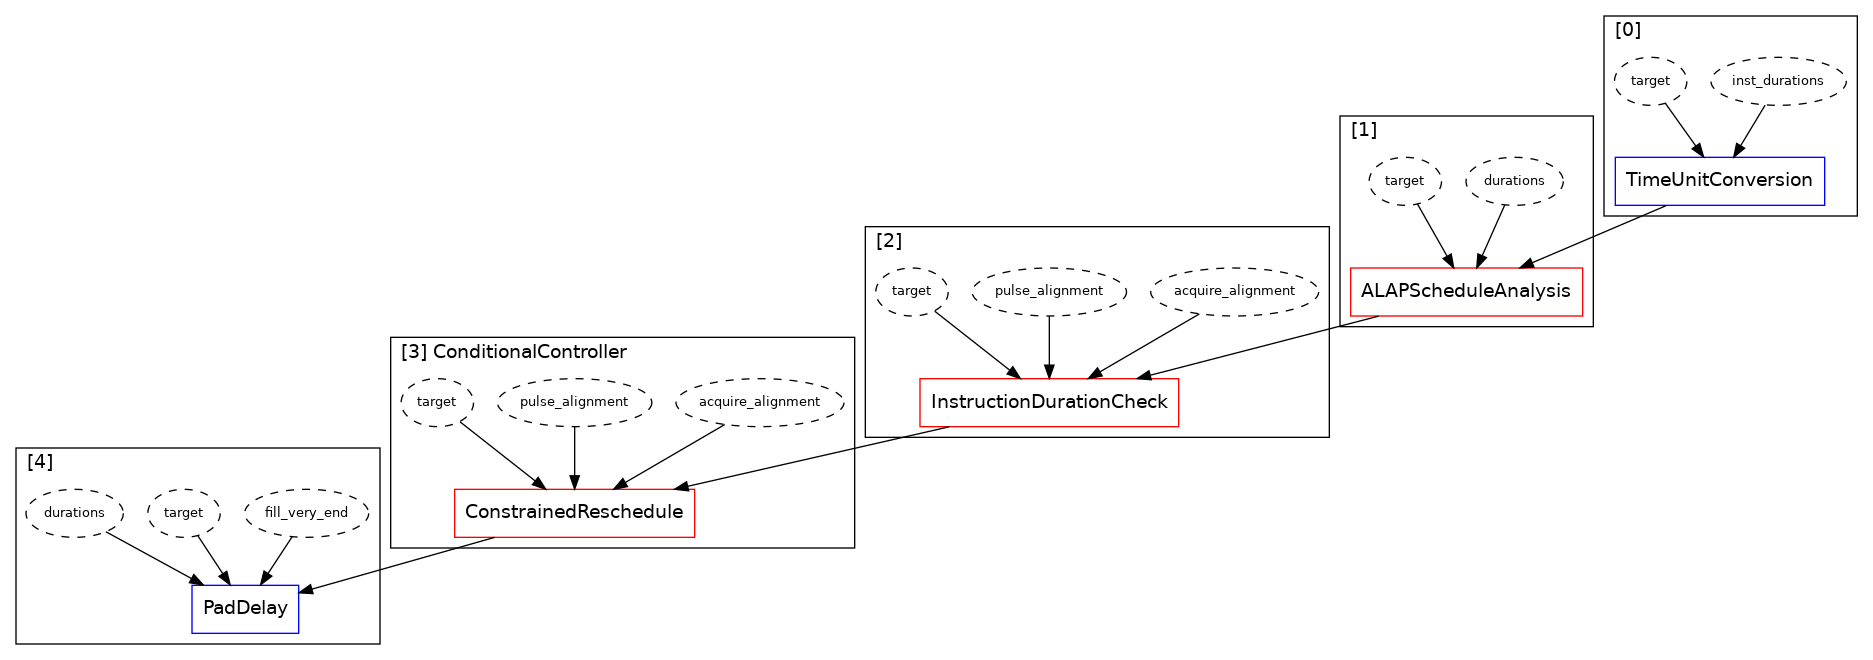

In [10]:
passmanagers_to_test['alap'].scheduling.draw()

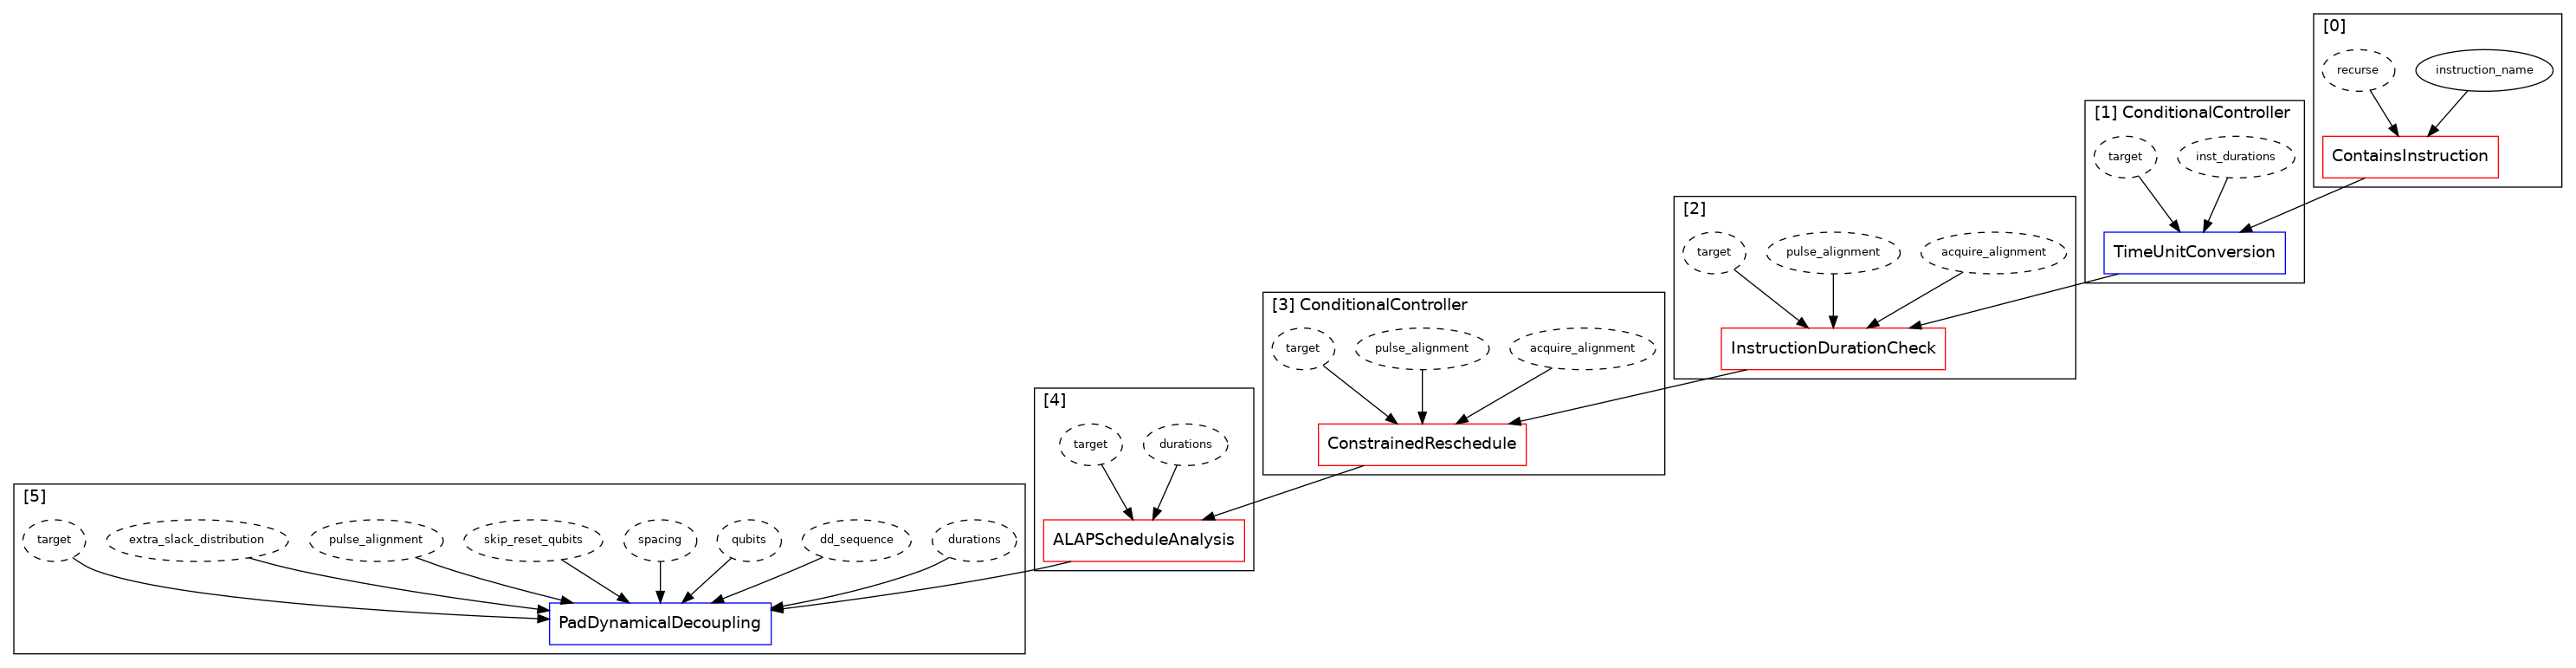

In [11]:
passmanagers_to_test['alap+dd+xx'].scheduling.draw()

## Main Transpilation

In [9]:
isa_circuits_dict = {}

for qubit in qubits:
    isa_circuits_dict[qubit] = {}
    for method in list(passmanagers_to_test.keys()):
        isa_circuits_dict[qubit][method] = mega_transpiler(circuit_dict[qubit], passmanagers_to_test[method], options_dict[method])

        

In [10]:
isa_circuits_dict

{7: {'none': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d16057d90>,
  'asap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1e60e110>,
  'alap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d160bac10>,
  'asap+dd+xx': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d16720f50>,
  'alap+dd+xx': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d15fcad10>,
  'alap+dd+xpxm': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d15e90150>,
  'asap+dd+xpxm': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d15651a50>,
  'asap+dd+xy': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d1567ced0>,
  'alap+dd+xy': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d15650190>},
 8: {'none': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d161bd050>,
  'asap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d15e63790>,
  'alap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x756d15d57a10>,
  'asap+dd+xx': <qiskit.circuit.quantumci

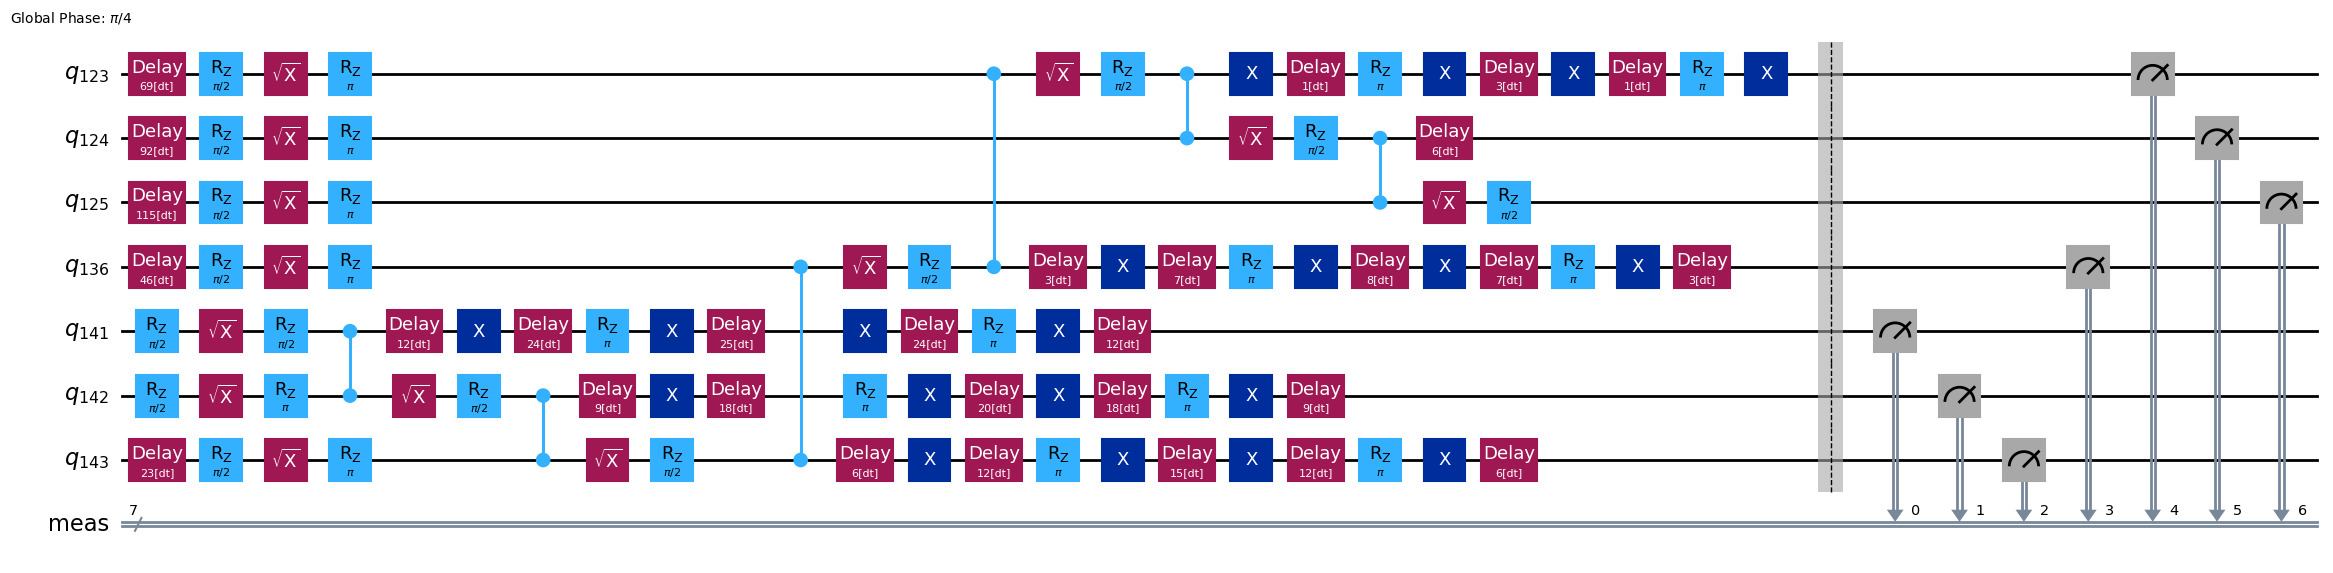

In [11]:
isa_circuits_dict[7]['alap+dd+xy'].draw("mpl", fold=-1, idle_wires=False)

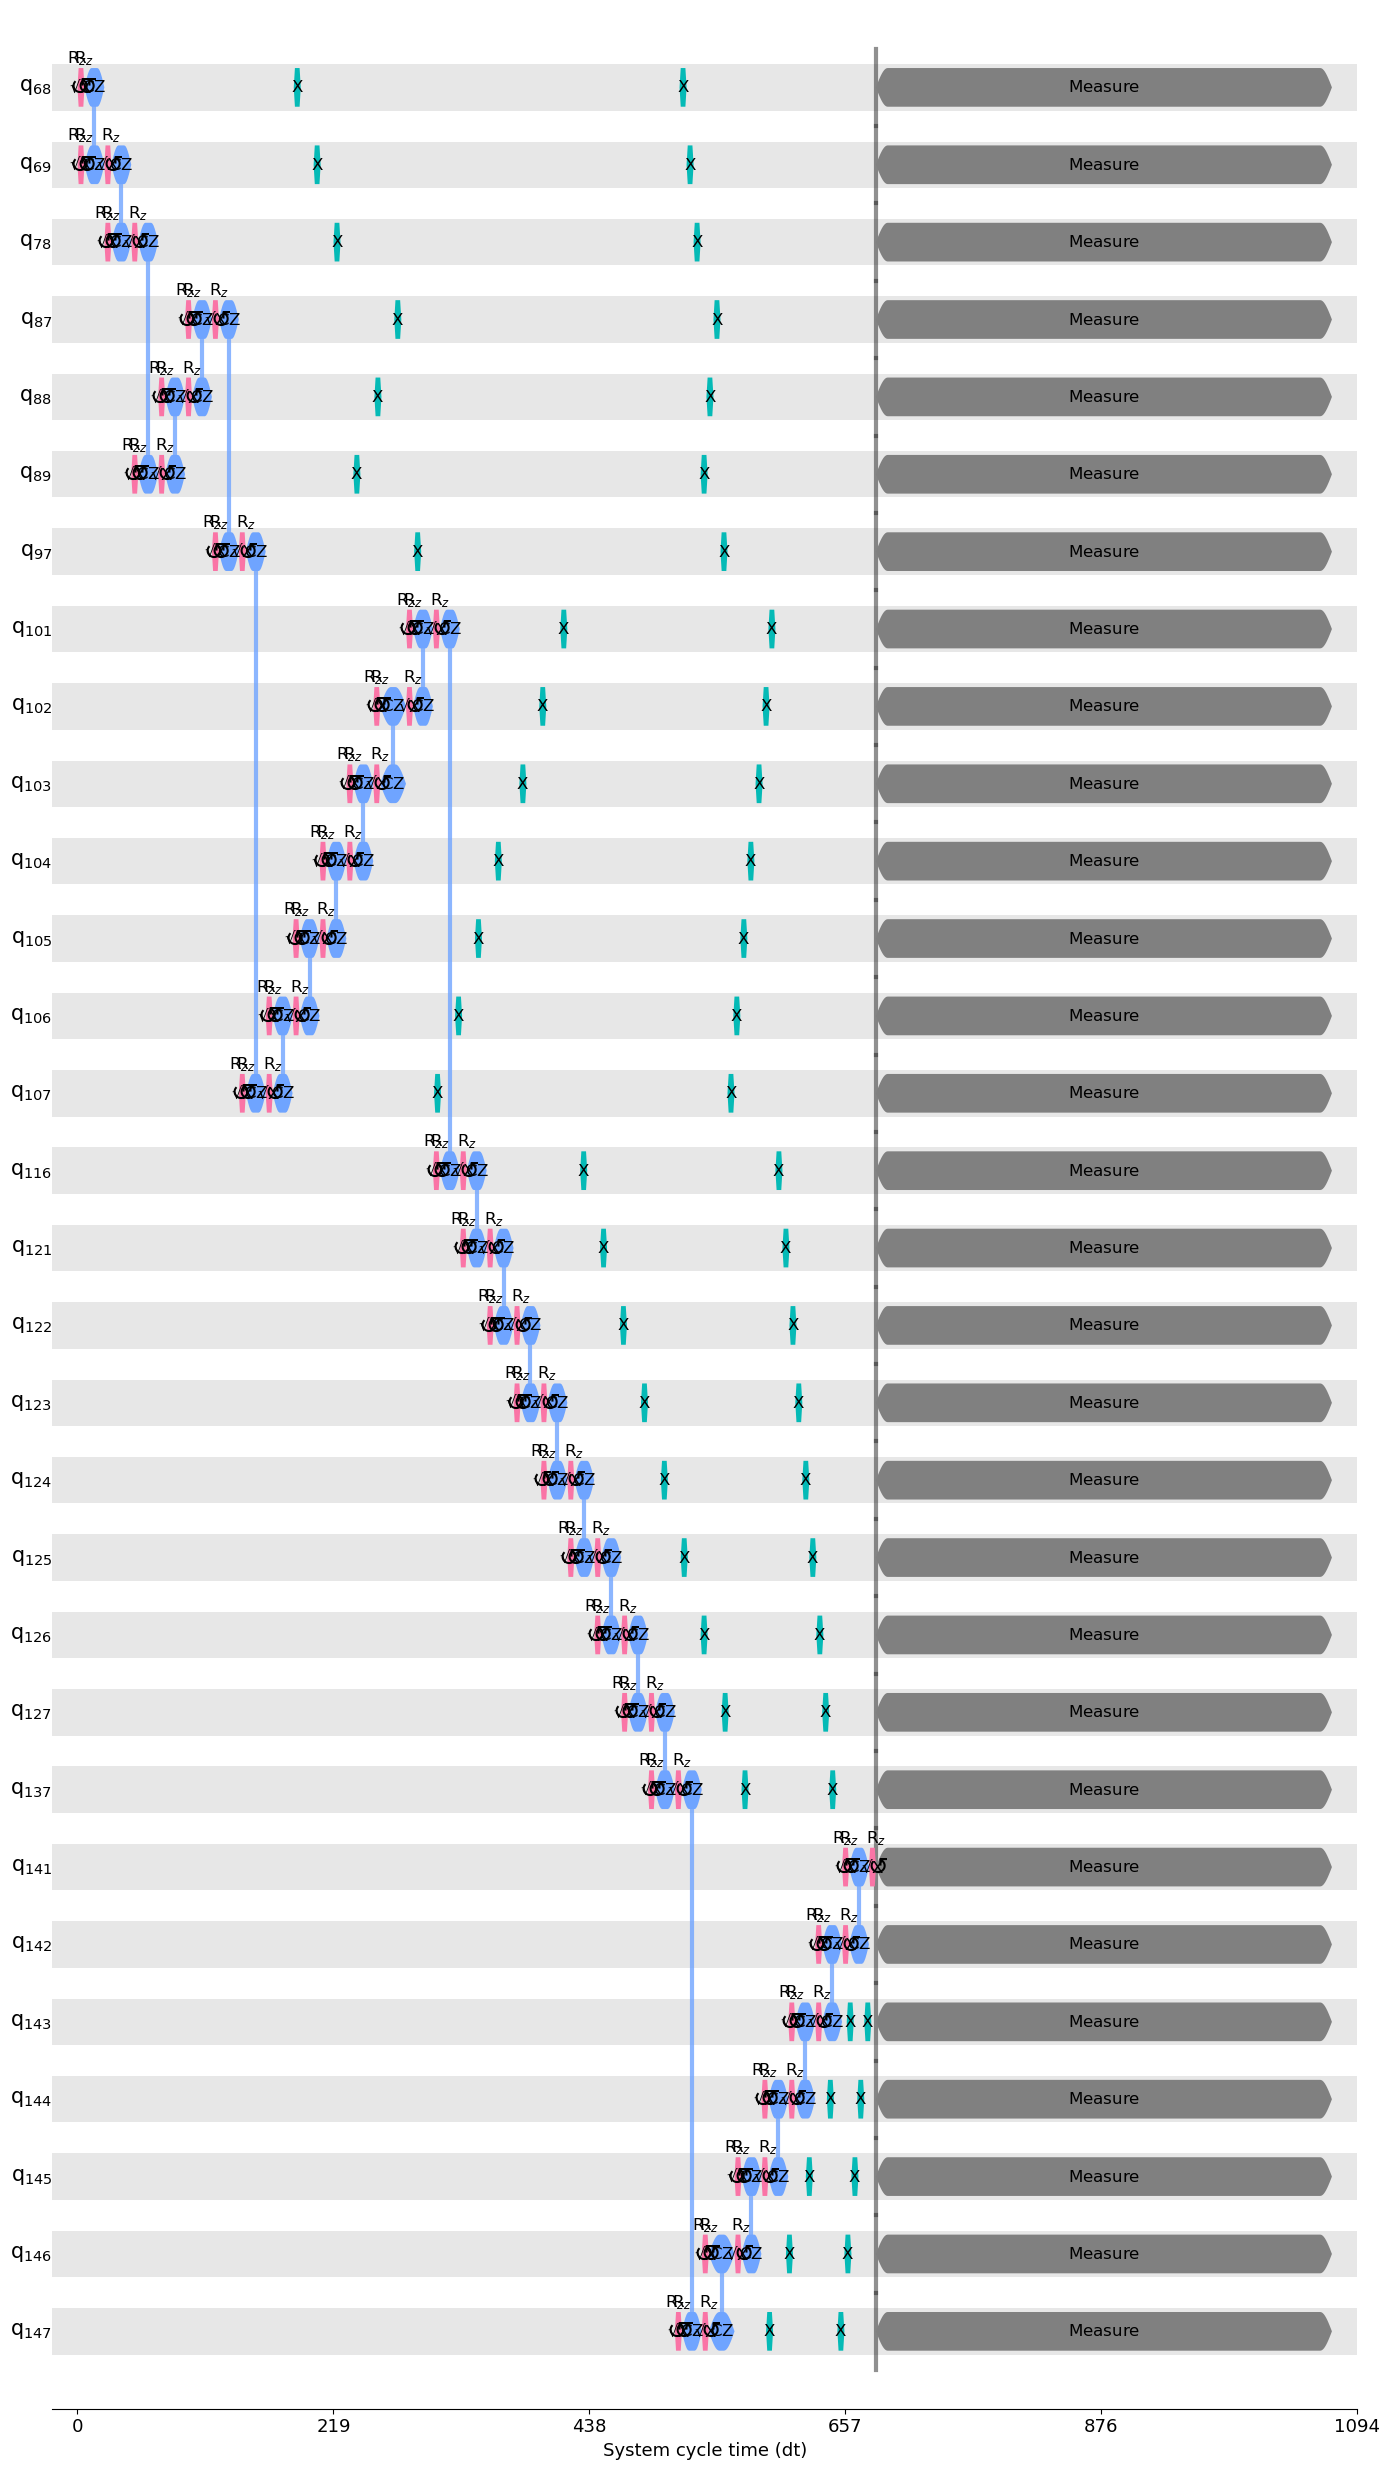

In [14]:
timeline_drawer(isa_circuits_dict[30]['alap+dd+xx'], idle_wires=False, target=fez.target)

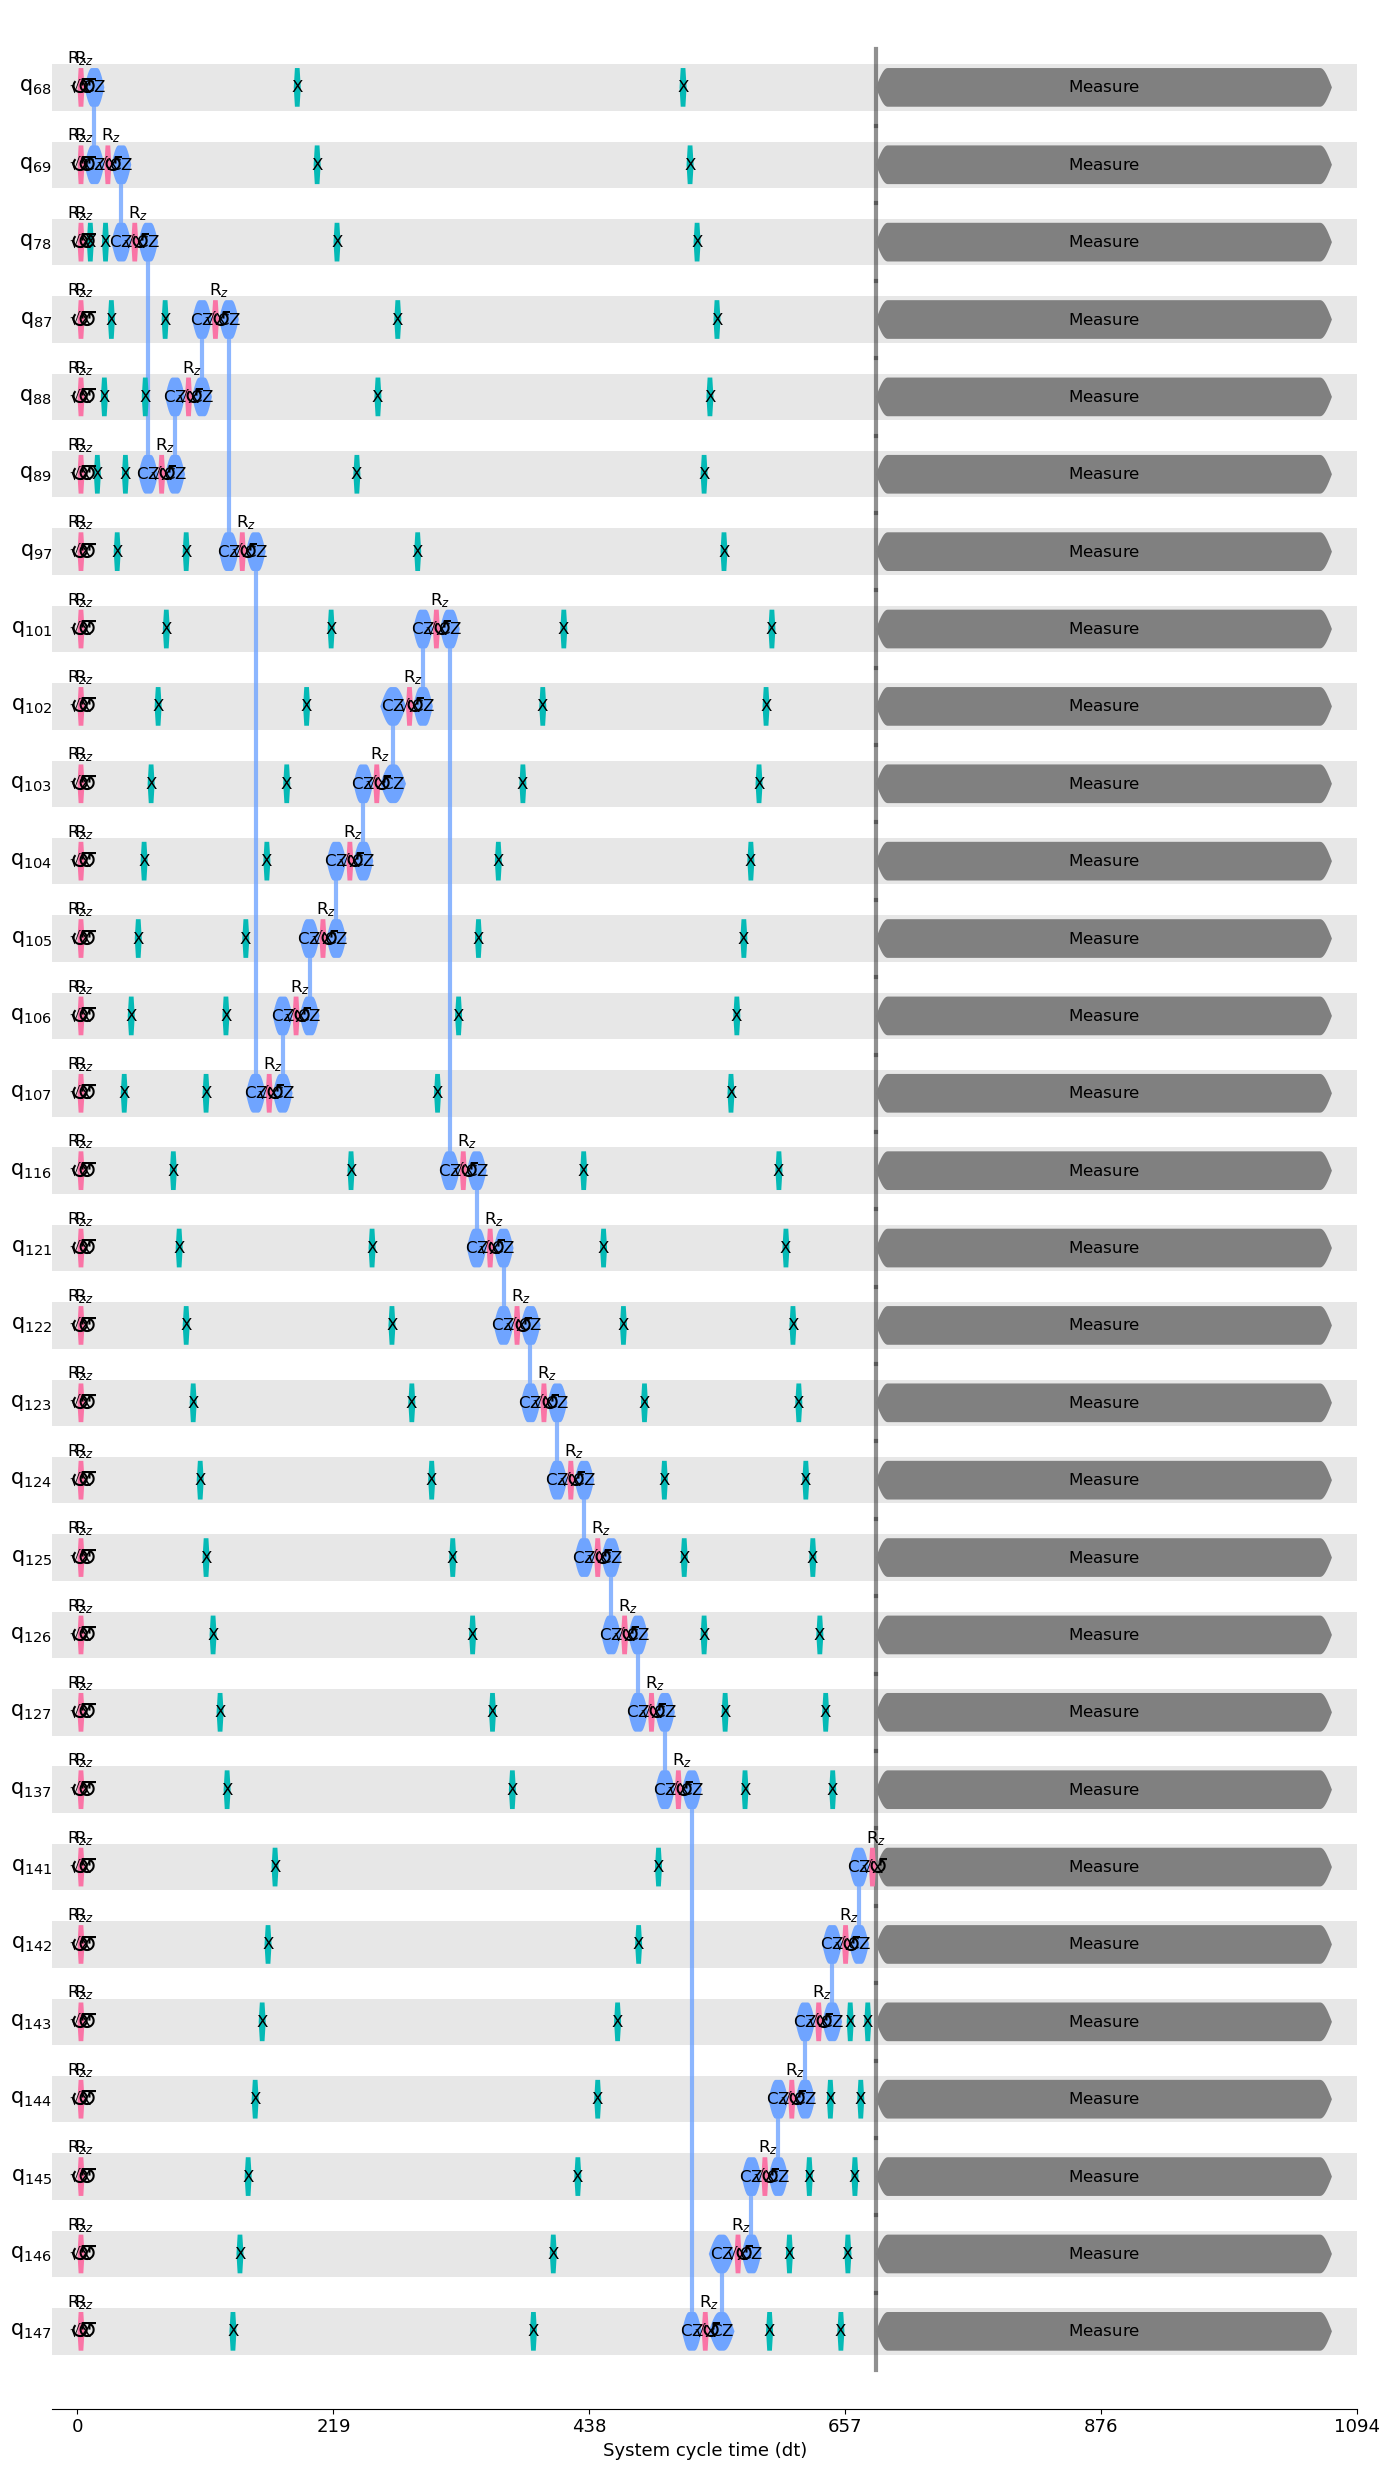

In [15]:
timeline_drawer(isa_circuits_dict[30]['asap+dd+xx'], idle_wires=False, target=fez.target)

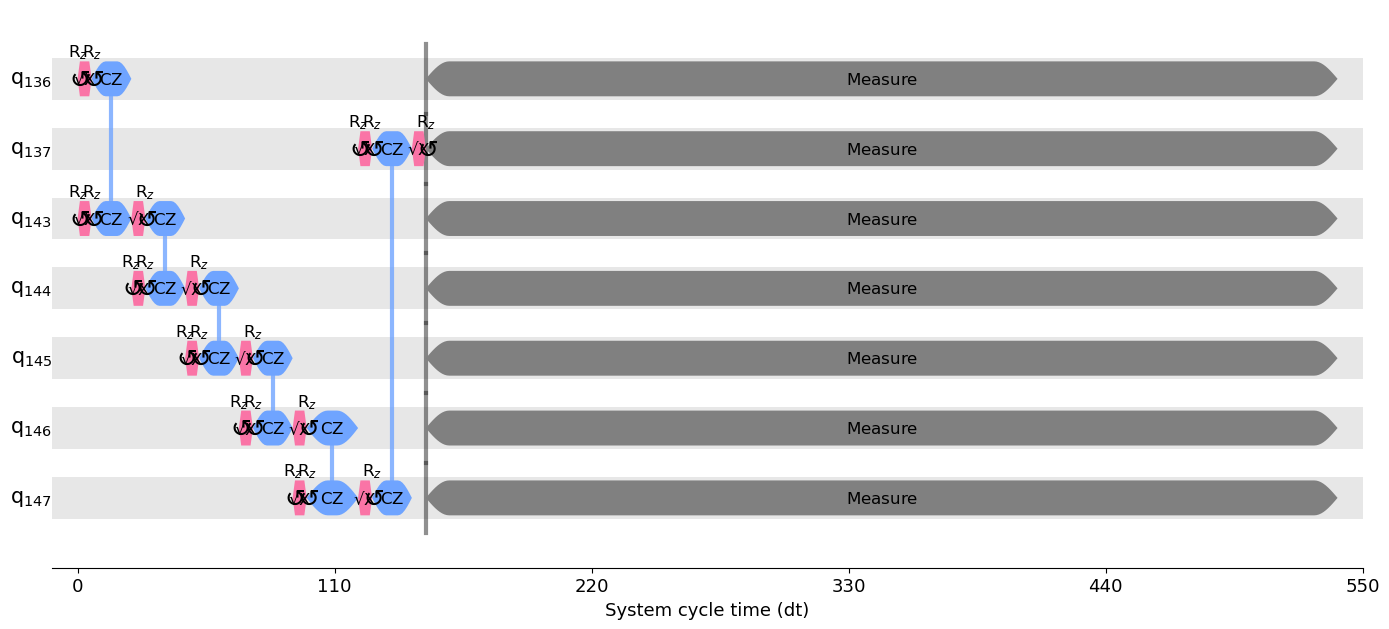

In [17]:
timeline_drawer(isa_circuits_dict[7]['none'], idle_wires=False, target=fez.target)

In [18]:
timeline_drawer(isa_circuits_dict[7]['alap+dd+xy'], idle_wires=False, target=fez.target)
isa_circuits_dict[7]['alap+dd+xy'].draw(idle_wires= False, fold=-1)

global phase: π/4
           ┌─────────┐       ┌────┐  ┌─────────┐            ┌───────────────┐   ┌───┐   ┌───────────────┐   ┌───────┐       ┌───┐   ┌───────────────┐     ┌───┐      ┌───────────────┐    ┌───────┐         ┌───┐      ┌───────────────┐                                                                                                                                             ░ ┌─┐                  
 q_136: ───┤ Rz(π/2) ├───────┤ √X ├──┤ Rz(π/2) ├──────────■─┤ Delay(12[dt]) ├───┤ X ├───┤ Delay(25[dt]) ├───┤ Rz(π) ├───────┤ X ├───┤ Delay(28[dt]) ├─────┤ X ├──────┤ Delay(25[dt]) ├────┤ Rz(π) ├─────────┤ X ├──────┤ Delay(12[dt]) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤M├──────────────────
        ┌──┴─────────┴───┐┌──┴────┴─┐└──┬────┬─┘┌───────┐ │ └───────────────┘   └───┘   └───────────────┘   └───────┘       └───┘   └───────────────┘     └───┘      └───────────────┘    └───────┘         └───┘      └───────────────┘                                                                   ┌────┐       ┌─────────┐                                                  ░ └╥┘               ┌─┐
 q_137: ┤ Delay(120[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■──────┤ √X ├───────┤ Rz(π/2) ├──────────────────────────────────────────────────░──╫────────────────┤M├
        └──┬─────────┬───┘└──┬────┬─┘ ┌─┴────┴┐ └───────┘ │       ┌────┐     ┌─────────┐                 ┌──────────────┐   ┌───┐   ┌───────────────┐   ┌───────┐          ┌───┐      ┌───────────────┐     ┌───┐      ┌───────────────┐    ┌───────┐      ┌───┐   ┌──────────────┐                 │      └────┘       └─────────┘                                                  ░  ║ ┌─┐            └╥┘
 q_143: ───┤ Rz(π/2) ├───────┤ √X ├───┤ Rz(π) ├───────────■───────┤ √X ├─────┤ Rz(π/2) ├────────■────────┤ Delay(9[dt]) ├───┤ X ├───┤ Delay(19[dt]) ├───┤ Rz(π) ├──────────┤ X ├──────┤ Delay(23[dt]) ├─────┤ X ├──────┤ Delay(19[dt]) ├────┤ Rz(π) ├──────┤ X ├───┤ Delay(9[dt]) ├─────────────────┼────────────────────────────────────────────────────────────────────────────────░──╫─┤M├─────────────╫─
        ┌──┴─────────┴──┐ ┌──┴────┴─┐ └─┬────┬┘ ┌───────┐         └────┘     └─────────┘        │        └────┬────┬────┘┌──┴───┴──┐└───────────────┘┌──┴───────┴───┐      ├───┤      ├───────────────┤   ┌─┴───┴─┐    └─────┬───┬─────┘┌───┴───────┴───┐  ├───┤  ┌┴──────────────┤   ┌───────┐     │      ┌───┐      ┌──────────────┐                                               ░  ║ └╥┘┌─┐          ║ 
 q_144: ┤ Delay(23[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────■─────────────┤ √X ├─────┤ Rz(π/2) ├────────■────────┤ Delay(7[dt]) ├──────┤ X ├──────┤ Delay(14[dt]) ├───┤ Rz(π) ├──────────┤ X ├──────┤ Delay(14[dt]) ├──┤ X ├──┤ Delay(14[dt]) ├───┤ Rz(π) ├─────┼──────┤ X ├──────┤ Delay(7[dt]) ├───────────────────────────────────────────────░──╫──╫─┤M├──────────╫─
        ├───────────────┤ ├─────────┤   ├────┤  ├───────┤                                                     └────┘     └─────────┘        │        └────┬────┬────┘   ┌──┴───┴──┐   └───────────────┘┌──┴───────┴───┐      ├───┤      └┬──────────────┤┌─┴───┴─┐└─────┬───┬─────┘┌──┴───────┴───┐ │      ├───┤      ├──────────────┤┌───────┐     ┌───┐      ┌──────────────┐      ░  ║  ║ └╥┘┌─┐       ║ 
 q_145: ┤ Delay(46[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├───────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├───────────■────────┤ Delay(4[dt]) ├──────┤ X ├───────┤ Delay(8[dt]) ├┤ Rz(π) ├──────┤ X ├──────┤ Delay(9[dt]) ├─┼──────┤ X ├──────┤ Delay(8[dt]) ├┤ Rz(π) ├─────┤ X ├──────┤ Delay(4[dt]) ├──────░──╫──╫──╫─┤M├───────╫─
        ├───

In [19]:
## The sampler pub should have all circuit with same num_qubits but different transpilation method. 
## The pubs are in this manner 
##       0               1                 2                3                         4                        5                        6                       
## [ isa_circuit, isa_circuit_asap, isa_circuit_alap, isa_circuit_asap_dd_xx, isa_circuit_alap_dd_xx, isa_circuit_asap_dd_xpxm, isa_circuit_alap_dd_xpxm]


valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

def build_sampler_pub(qubit, valid_methods):
    circuits_dict = isa_circuits_dict[qubit]

    sampler_pub = []

    for method in valid_methods:
        sampler_pub.append( (circuits_dict[method]) )

    return sampler_pub


pubs_dict = {qubit:build_sampler_pub(qubit, valid_methods) for qubit in qubits}




dict_keys(['rz', 'delay', 'id', 'measure', 'if_else', 'cz', 'reset', 'sx', 'x'])


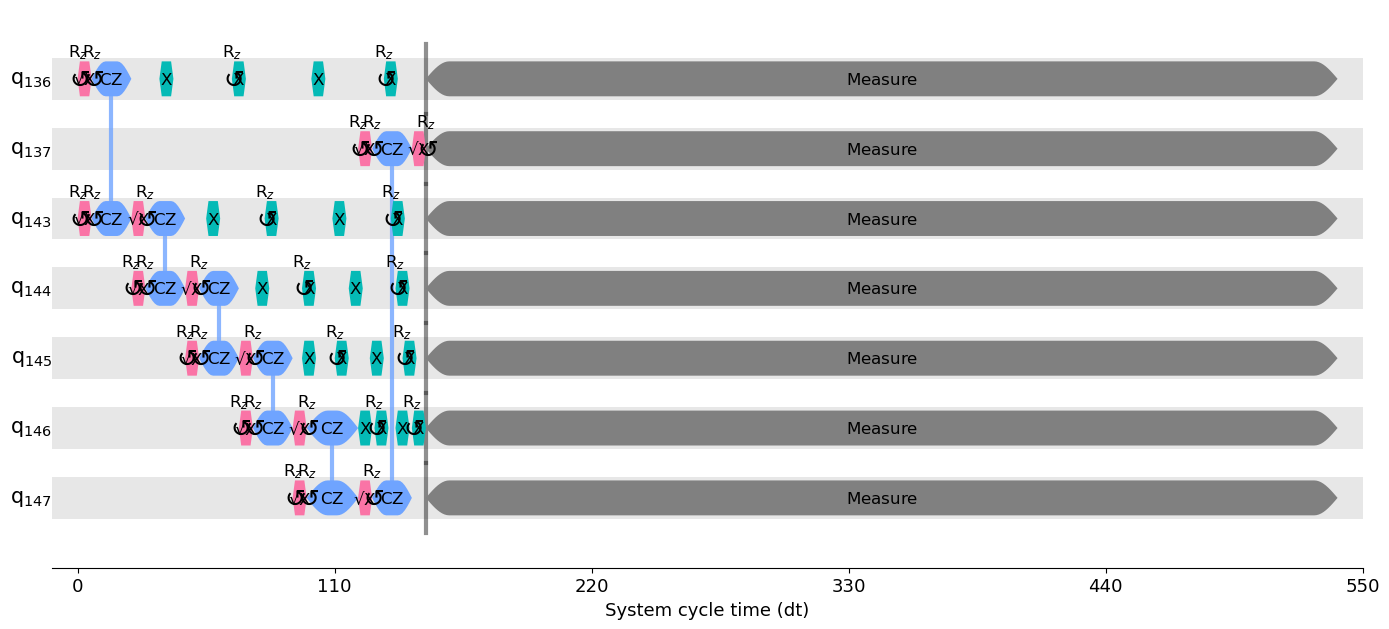

In [21]:
print(fez.target.operation_names)
timeline_drawer(pubs_dict[7][8], idle_wires=False, target=fez.target)

### Saving necessary objects for repeatibility

In [ ]:
# isa_circuits_dill = "extensive_benchmarking_isa_circuits.dill"
# passmanagers_dill = "extensive_benchmarking_passmanagers.dill"
# save_object(pubs_dict, filename=isa_circuits_dill)
# save_object(passmanagers_to_test, filename=passmanagers_dill)

Object saved to 'extensive_benchmarking_isa_circuits.dill'
Object saved to 'extensive_benchmarking_passmanagers.dill'


### Loading objects

In [23]:
# load_isa_circuits = load_object(isa_circuits_dill)

In [24]:
# timeline_drawer(load_isa_circuits[7][7], idle_wires=False, target=fez.target)

## HARDWARE EXECUTION CELL. DO NOT RUN UNLESS NECESSARY

In [ ]:
# hardware_job_dict = {i:{qubit:execute_on_hardware(fez, pubs_dict[qubit]) for qubit in qubits} for i in range(3)}

d4slsksfitbs739j43k0
d4slsls5fjns73d2jje0
d4slsmbher1c73bdfi7g
d4slsmsfitbs739j43n0
d4slsnk5fjns73d2jjgg
d4slso45fjns73d2jjh0
d4slsovt3pms7399d6r0
d4slspft3pms7399d6sg
d4slsps5fjns73d2jjjg
d4slsqk5fjns73d2jjkg
d4slsr4fitbs739j43t0
d4slsrk5fjns73d2jjm0
d4slss3her1c73bdfif0
d4slsss5fjns73d2jjog
d4slstcfitbs739j440g
d4slstvt3pms7399d720
d4slsucfitbs739j4430
d4slsusfitbs739j4450
d4slsvk5fjns73d2jjt0
d4slt045fjns73d2jjug
d4slt0rher1c73bdfilg
d4slt1ft3pms7399d76g
d4slt1vt3pms7399d77g
d4slt2c5fjns73d2jk40
d4slt345fjns73d2jk50
d4slt3ft3pms7399d7ag
d4slt43her1c73bdfip0
d4slt4k5fjns73d2jk7g
d4slt54fitbs739j44eg
d4slt5jher1c73bdfirg
d4slt6cfitbs739j44h0
d4slt73her1c73bdfit0
d4slt7kfitbs739j44k0
d4slt84fitbs739j44l0
d4slt8jher1c73bdfivg
d4slt945fjns73d2jkeg


In [ ]:
# hardware_job_dill = "extensive_benchmarking_hardware_job.dill"
# save_object(hardware_job_dict, hardware_job_dill)

Object saved to 'extensive_benchmarking_hardware_job.dill'


## Simulate circuits on AerSimulator (Noiseless)

In [5]:
service = QiskitRuntimeService()

management.get:WARNING:2025-12-11 15:03:49,171: Loading default saved account


In [6]:
qubits = [7, 8, 9, 10, 17, 18, 19, 20, 27, 28, 29, 30]


methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list

isa_circuits_dict = load_object("extensive_benchmarking_isa_circuits.dill")
hardware_job_dict = load_object("extensive_benchmarking_hardware_job.dill")


noiseless_backend = AerSimulator()

noiseless_pub = [(isa_circuits_dict[qubit][0]) for qubit in qubits]


with Batch(backend=noiseless_backend) as batch:
    noiseless_sampler = naked_sampler(mode=batch)
    noiseless_job = noiseless_sampler.run(noiseless_pub, shots=4096)
    noiseless_result = noiseless_job.result()

Object loaded from 'extensive_benchmarking_isa_circuits.dill'
Object loaded from 'extensive_benchmarking_hardware_job.dill'


/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [7]:
simulated_counts = { noiseless_result[i].data.meas.num_bits:noiseless_result[i].data.meas.get_counts() for i in range(len(noiseless_result)) }
simulated_counts

{7: {'1111111': 2153, '0000000': 1943},
 8: {'11111111': 2074, '00000000': 2022},
 9: {'111111111': 2070, '000000000': 2026},
 10: {'1111111111': 2017, '0000000000': 2079},
 17: {'00000000000000000': 2081, '11111111111111111': 2015},
 18: {'111111111111111111': 2050, '000000000000000000': 2046},
 19: {'1111111111111111111': 2078, '0000000000000000000': 2018},
 20: {'11111111111111111111': 2022, '00000000000000000000': 2074},
 27: {'000000000000000000000000000': 2100,
  '111111111111111111111111111': 1996},
 28: {'1111111111111111111111111111': 2081,
  '0000000000000000000000000000': 2015},
 29: {'00000000000000000000000000000': 2034,
  '11111111111111111111111111111': 2062},
 30: {'000000000000000000000000000000': 2036,
  '111111111111111111111111111111': 2060}}

## Data Analysis

In [8]:

def store_data(service, job_dict, simulated, valid_methods):
    
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "ideal_counts", "simulated_counts"] + valid_methods + ["hellinger_fidelity(ideal)", "hellinger_fidelity(simulated)"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
            shots = result[0].data.meas.num_shots
            data_list.append(shots)
            
            # 3 Ideal_counts
            ideal = {'1'*int(qubit):int(shots/2), '0'*int(qubit):int(shots/2)}
            data_list.append(ideal)
            
            # 4 Simulated_counts
            simulated_counts = simulated[qubit]
            data_list.append(simulated_counts)

            # storing 
            for i in range(len(valid_methods)):
                data_list.append(result[i].data.meas.get_counts())


            # 8 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
            data_list += get_fidelity_for_circuit(ideal, simulated_counts, [result[i].data.meas.get_counts() for i in range(len(valid_methods))])

        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [9]:
experiment_results = store_data(service, hardware_job_dict, simulated_counts, valid_methods)

In [10]:
experiment_results.to_csv("Fez-GHZ-extensive-benchmarking-sampler.csv", index=False)

In [1]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

qubits = [7, 8, 9, 10, 17, 18, 19, 20, 27, 28, 29, 30]


methods_list    = ["none", "asap", "alap"] 
dd_methods_list = ["asap+dd+xx", "alap+dd+xx", "alap+dd+xpxm", "asap+dd+xpxm"]
extra_dd_methods_list = ["asap+dd+xy", "alap+dd+xy"]

valid_methods = methods_list + dd_methods_list + extra_dd_methods_list


In [2]:
valid_methods

['none',
 'asap',
 'alap',
 'asap+dd+xx',
 'alap+dd+xx',
 'alap+dd+xpxm',
 'asap+dd+xpxm',
 'asap+dd+xy',
 'alap+dd+xy']

In [3]:
# Read the CSV file
df = pd.read_csv("Fez-GHZ-extensive-benchmarking-sampler.csv")

# List of columns that contain string representations of dictionaries
# Based on the columns shown in your traceback
cols_to_eval = df.columns

def safe_literal_eval(val):
    """
    Safely evaluate a string containing a Python literal.
    Returns the original value if it's not a string or if evaluation fails.
    """
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return val
    return val

# Apply the conversion only to the relevant columns
for col in cols_to_eval:
    if col in df.columns:
        df[col] = df[col].apply(safe_literal_eval)

# Verify the data types
df.head()


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,none,asap,alap,asap+dd+xx,alap+dd+xx,alap+dd+xpxm,asap+dd+xpxm,asap+dd+xy,alap+dd+xy,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4slsksfitbs739j43k0,7,4096,"{'1111111': 2048, '0000000': 2048}","{'1111111': 2153, '0000000': 1943}","{'0000000': 1928, '0100000': 15, '1111111': 16...","{'1111111': 1665, '0000000': 1879, '0000010': ...","{'0000000': 1907, '1111111': 1672, '0001111': ...","{'0000000': 1805, '1011000': 1, '1111111': 163...","{'1111111': 1602, '0000000': 1857, '0000001': ...","{'1111111': 1615, '0000000': 1880, '0000011': ...","{'0000000': 1833, '1111111': 1622, '1100000': ...","{'1111111': 1642, '0000000': 1892, '0111111': ...","{'1111111': 1707, '0000000': 1827, '0010111': ...","[0.9993424263882965, 0.8767808045734468, 0.864...","[0.8745778053258384, 0.8625377175627317, 0.870..."
1,0,d4slsls5fjns73d2jje0,8,4096,"{'11111111': 2048, '00000000': 2048}","{'11111111': 2074, '00000000': 2022}","{'11111111': 1573, '00000000': 1931, '11101111...","{'11111111': 1564, '00000000': 1832, '00111111...","{'00000000': 1882, '11111111': 1671, '11011111...","{'00000000': 1823, '01000000': 14, '11111111':...","{'00000000': 1856, '11111111': 1595, '11110111...","{'11011101': 1, '11111111': 1628, '00000000': ...","{'00000000': 1790, '11111111': 1588, '11111011...","{'11100001': 1, '00000000': 1816, '11111111': ...","{'11111111': 1602, '00000000': 1896, '11111100...","[0.9999597056364962, 0.8532304421185956, 0.827...","[0.8526413518986303, 0.8273600489160481, 0.866..."
2,0,d4slsmbher1c73bdfi7g,9,4096,"{'111111111': 2048, '000000000': 2048}","{'111111111': 2070, '000000000': 2026}","{'111111111': 1355, '000000000': 1878, '111111...","{'111111111': 1325, '000000000': 1748, '110000...","{'111011111': 48, '111111111': 1427, '00000000...","{'111111111': 1315, '000000000': 1808, '111111...","{'101111111': 22, '111111111': 1364, '11111111...","{'111111110': 224, '000000000': 1846, '1111111...","{'000000000': 1766, '111111111': 1364, '111111...","{'000000000': 1803, '000000001': 57, '00100000...","{'000000000': 1847, '111111111': 1414, '011111...","[0.9999711505196361, 0.7841085083810232, 0.746...","[0.783400226178636, 0.7460971830501215, 0.7981..."
3,0,d4slsmsfitbs739j43n0,10,4096,"{'1111111111': 2048, '0000000000': 2048}","{'1111111111': 2017, '0000000000': 2079}","{'0000000000': 1874, '1111111111': 1337, '1011...","{'1010000000': 6, '1011011111': 4, '1111111111...","{'1111111111': 1368, '0000000000': 1898, '1011...","{'0000000000': 1707, '1111111111': 1373, '0000...","{'0000100000': 40, '0000000000': 1762, '111111...","{'1111111111': 1354, '0000000000': 1853, '1000...","{'0000111111': 21, '1111111111': 1353, '110000...","{'1111111111': 1365, '0000000000': 1721, '0111...","{'0000000000': 1851, '1011111111': 202, '11111...","[0.9999427166549892, 0.7784153151055028, 0.754...","[0.7793632796113626, 0.7556117094632328, 0.793..."
4,0,d4slsnk5fjns73d2jjgg,17,4096,"{'11111111111111111': 2048, '00000000000000000...","{'00000000000000000': 2081, '11111111111111111...","{'11111101111111111': 152, '11111111000000000'...","{'00000000000000000': 1432, '11111111110111111...","{'00000000000000000': 1759, '11111111111111111...","{'11100000000000000': 21, '00000000000000000':...","{'00000000000000111': 23, '11111111111111111':...","{'11111100111111111': 1, '00000000000000000': ...","{'11111000000011111': 2, '00000000000000000': ...","{'00000000000000000': 1314, '11111110111111111...","{'00000000000000000': 1461, '00000000000000010...","[0.9999350863280547, 0.6503878072638585, 0.544...","[0.651677897221708, 0.5453979926742467, 0.6634..."


In [4]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]
qubit_7


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,none,asap,alap,asap+dd+xx,alap+dd+xx,alap+dd+xpxm,asap+dd+xpxm,asap+dd+xy,alap+dd+xy,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4slsksfitbs739j43k0,7,4096,"{'1111111': 2048, '0000000': 2048}","{'1111111': 2153, '0000000': 1943}","{'0000000': 1928, '0100000': 15, '1111111': 16...","{'1111111': 1665, '0000000': 1879, '0000010': ...","{'0000000': 1907, '1111111': 1672, '0001111': ...","{'0000000': 1805, '1011000': 1, '1111111': 163...","{'1111111': 1602, '0000000': 1857, '0000001': ...","{'1111111': 1615, '0000000': 1880, '0000011': ...","{'0000000': 1833, '1111111': 1622, '1100000': ...","{'1111111': 1642, '0000000': 1892, '0111111': ...","{'1111111': 1707, '0000000': 1827, '0010111': ...","[0.9993424263882965, 0.8767808045734468, 0.864...","[0.8745778053258384, 0.8625377175627317, 0.870..."
12,1,d4slss3her1c73bdfif0,7,4096,"{'1111111': 2048, '0000000': 2048}","{'1111111': 2153, '0000000': 1943}","{'0000000': 1951, '1110111': 52, '1111111': 16...","{'0000000': 1885, '0000011': 10, '0000111': 37...","{'1111111': 1596, '0000000': 1941, '1111101': ...","{'0000000': 1820, '0000111': 35, '1111111': 16...","{'1111011': 16, '1111111': 1644, '0000000': 18...","{'0000000': 1814, '1111111': 1700, '0001111': ...","{'1111111': 1630, '0000000': 1892, '1110000': ...","{'0000000': 1896, '0011111': 36, '1111111': 16...","{'1111111': 1675, '0101011': 1, '0000000': 188...","[0.9993424263882965, 0.878376302459881, 0.8648...","[0.8759346666884639, 0.8628881031060899, 0.858..."
24,2,d4slt345fjns73d2jk50,7,4096,"{'1111111': 2048, '0000000': 2048}","{'1111111': 2153, '0000000': 1943}","{'0000000': 1913, '1111111': 1660, '1110000': ...","{'0000000': 1872, '1111111': 1696, '0000111': ...","{'1111111': 1682, '0000000': 1902, '1111101': ...","{'0000000': 1897, '1111111': 1592, '1111101': ...","{'0000000': 1891, '0010000': 2, '1111111': 167...","{'0000010': 30, '0000000': 1849, '1111011': 15...","{'0000111': 29, '1111111': 1603, '0000000': 19...","{'0000000': 1862, '1111111': 1641, '1101111': ...","{'1111111': 1643, '0000000': 1928, '0111111': ...","[0.9993424263882965, 0.8712196563996845, 0.870...","[0.8690640878646171, 0.8688899387929953, 0.872..."


In [5]:
iterations = 3
for i in range(iterations):
    print(qubit_7.iloc[i, 15])
    
print(qubit_7["hellinger_fidelity(ideal)"])
print("..............................................................................................")
for i in range(iterations):
    print(qubit_7.iloc[i, 16])
print(qubit_7["hellinger_fidelity(simulated)"])


[0.9993424263882965, 0.8767808045734468, 0.8644449510150116, 0.8728364895602589, 0.840081483570755, 0.843333471858235, 0.8520433378731447, 0.8427186279367492, 0.8617121872682295, 0.8625441968934803]
[0.9993424263882965, 0.878376302459881, 0.8648581437638151, 0.8614665635199167, 0.8456579191909105, 0.8608026179715526, 0.8576843674887542, 0.8586720519481147, 0.8679644541101408, 0.8693322015339568]
[0.9993424263882965, 0.8712196563996845, 0.8705635435922795, 0.8741749750079776, 0.8501761779562036, 0.8698061773736622, 0.8515451085655552, 0.8546214547993966, 0.8543727708816949, 0.8704356649521975]
0     [0.9993424263882965, 0.8767808045734468, 0.864...
12    [0.9993424263882965, 0.878376302459881, 0.8648...
24    [0.9993424263882965, 0.8712196563996845, 0.870...
Name: hellinger_fidelity(ideal), dtype: object
..............................................................................................
[0.8745778053258384, 0.8625377175627317, 0.8707924106727707, 0.8384842260033166, 0.8411837

In [6]:
def get_labels_and_fidelity_data(data, qubit, valid_methods):

    # Returns valid_methods, output_list
    
    qubit_df = data[data["Qubit"] == qubit]

    output_dict = {method:[] for method in valid_methods}
    
    for i in range(iterations):
        hf = qubit_df.iloc[i, 15]
        alt_hf = qubit_df.iloc[i, 16]
        
        # print(f"For qubit: {qubit} \n Hellinger Fidelity wrt ideal (simulated, no_dd, dd):\n {hf} \n Hellinger Fidelity wrt simulated (no_dd, dd):\n {alt_hf} \n")
        for method in valid_methods:
            output_dict[method].append(alt_hf[valid_methods.index(method)])

            
    return output_dict



In [7]:
fidelity_dict = {qubit:get_labels_and_fidelity_data(df, qubit, valid_methods) for qubit in qubits}
fidelity_dict




{7: {'none': [0.8745778053258384, 0.8759346666884639, 0.8690640878646171],
  'asap': [0.8625377175627317, 0.8628881031060899, 0.8688899387929953],
  'alap': [0.8707924106727707, 0.8587422614137681, 0.8722238158327529],
  'asap+dd+xx': [0.8384842260033166, 0.8440132108056883, 0.8477093579365745],
  'alap+dd+xx': [0.8411837591766259, 0.8587226895017662, 0.8678829080335357],
  'alap+dd+xpxm': [0.8498253650139873, 0.8564070577562927, 0.8496901410762401],
  'asap+dd+xpxm': [0.8408444551625485, 0.85646847140883, 0.8521767122648614],
  'asap+dd+xy': [0.859581636841027, 0.8659360888332988, 0.852428392257507],
  'alap+dd+xy': [0.8612261556523135, 0.867421751436378, 0.868080534793995]},
 8: {'none': [0.8526413518986303, 0.8599533775859898, 0.8619702880850586],
  'asap': [0.8273600489160481, 0.8267540209914246, 0.8395681359938201],
  'alap': [0.8663042797992173, 0.8617171194582701, 0.8636442638720082],
  'asap+dd+xx': [0.8311222395262918, 0.8284749536950466, 0.8332003220253441],
  'alap+dd+xx': [

### None vs ASAP vs ALAP scheduling

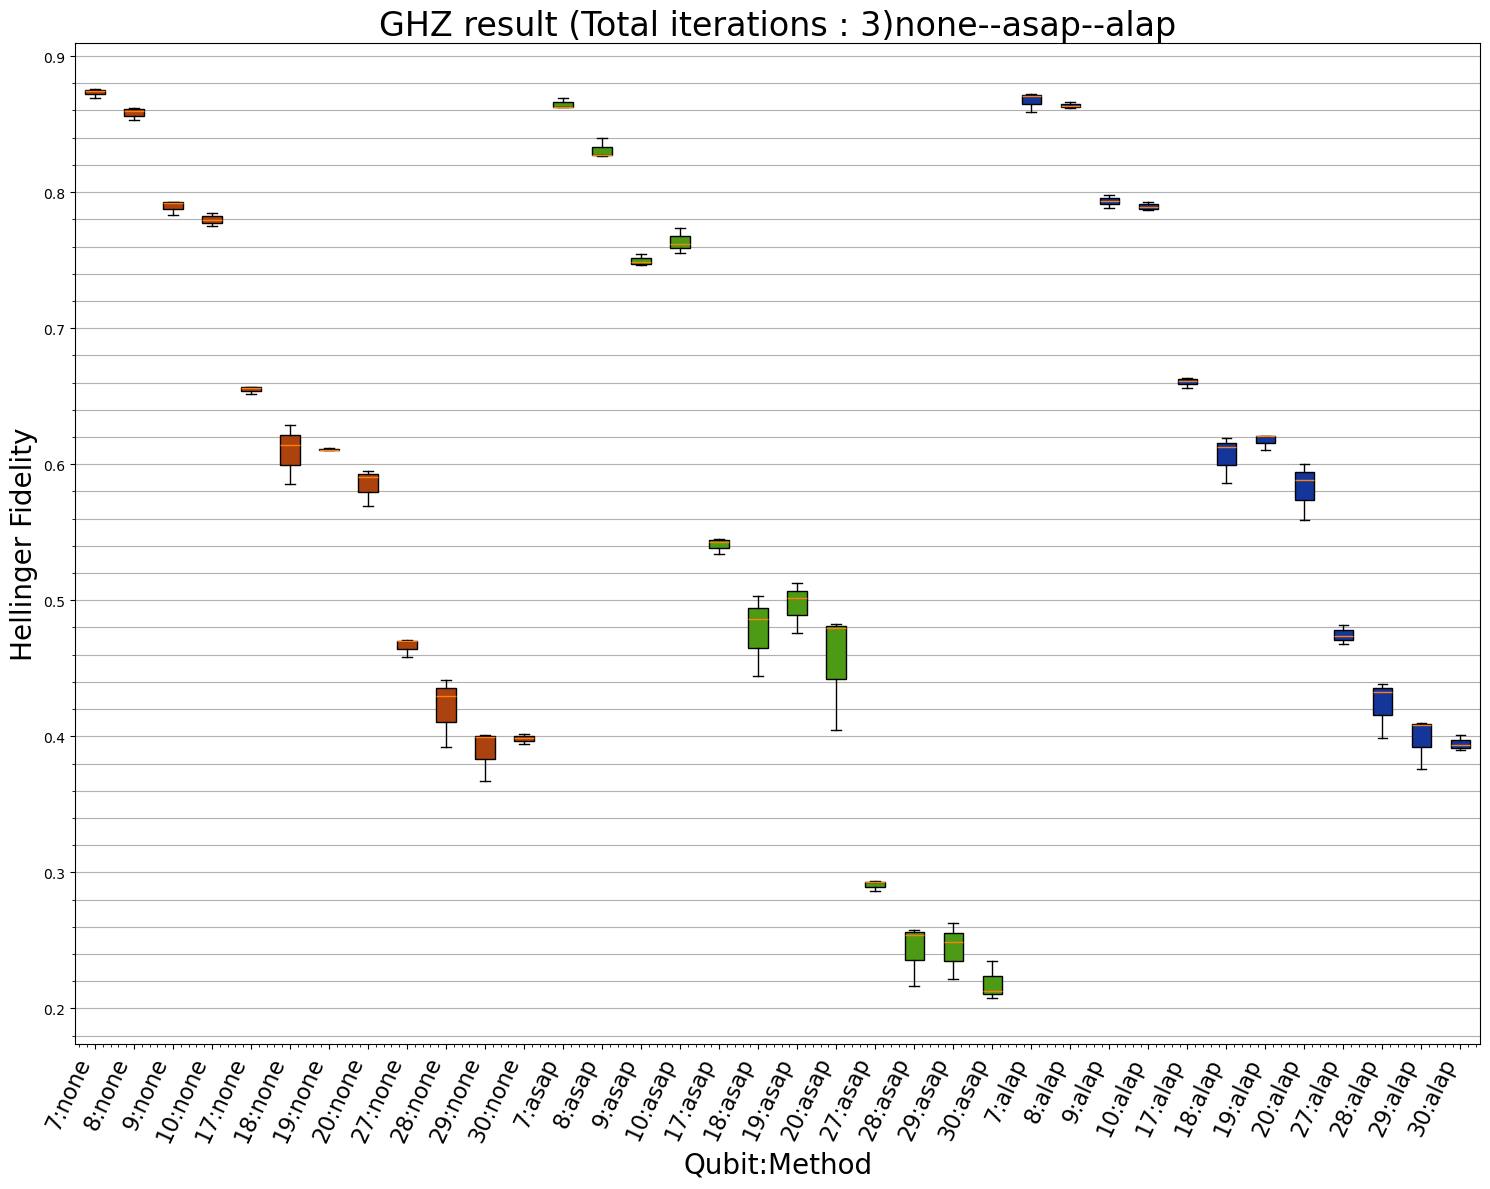

In [10]:
import matplotlib.pyplot as plt
plot_methods = ["none", "asap", "alap"]
labels = [f"{qubit}:{method}" for method in plot_methods for qubit in qubits] 

data_for_label = []
for method in plot_methods:
    for qubit in qubits:
        data_for_label += [fidelity_dict[qubit][method]]


colors = ["#AC420D" for _ in qubits] + ["#4D9B14" for _ in qubits] + ["#14369B" for _ in qubits]

fig, ax = plt.subplots(figsize=(15, 12))
ax.set_ylabel('Hellinger Fidelity', fontsize=20)
ax.set_title(f"GHZ result (Total iterations : {iterations})"+'--'.join(plot_methods), fontsize=24)


bplot = ax.boxplot(data_for_label,
                   patch_artist=True,  # fill with color
                   meanline=True, meanprops=dict(color="#970B0B", linewidth=2), manage_ticks=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticklabels(labels, rotation=65, ha='right', fontsize=16)

ax.minorticks_on()
ax.set_xlabel("Qubit:Method", fontsize=20)
ax.grid(True, which = 'both' , axis="y")
plt.tight_layout()
plt.savefig("Fez_DD_GHZ_Sampler--"+'--'.join(plot_methods)+".png")
plt.show()

### ASAP performance

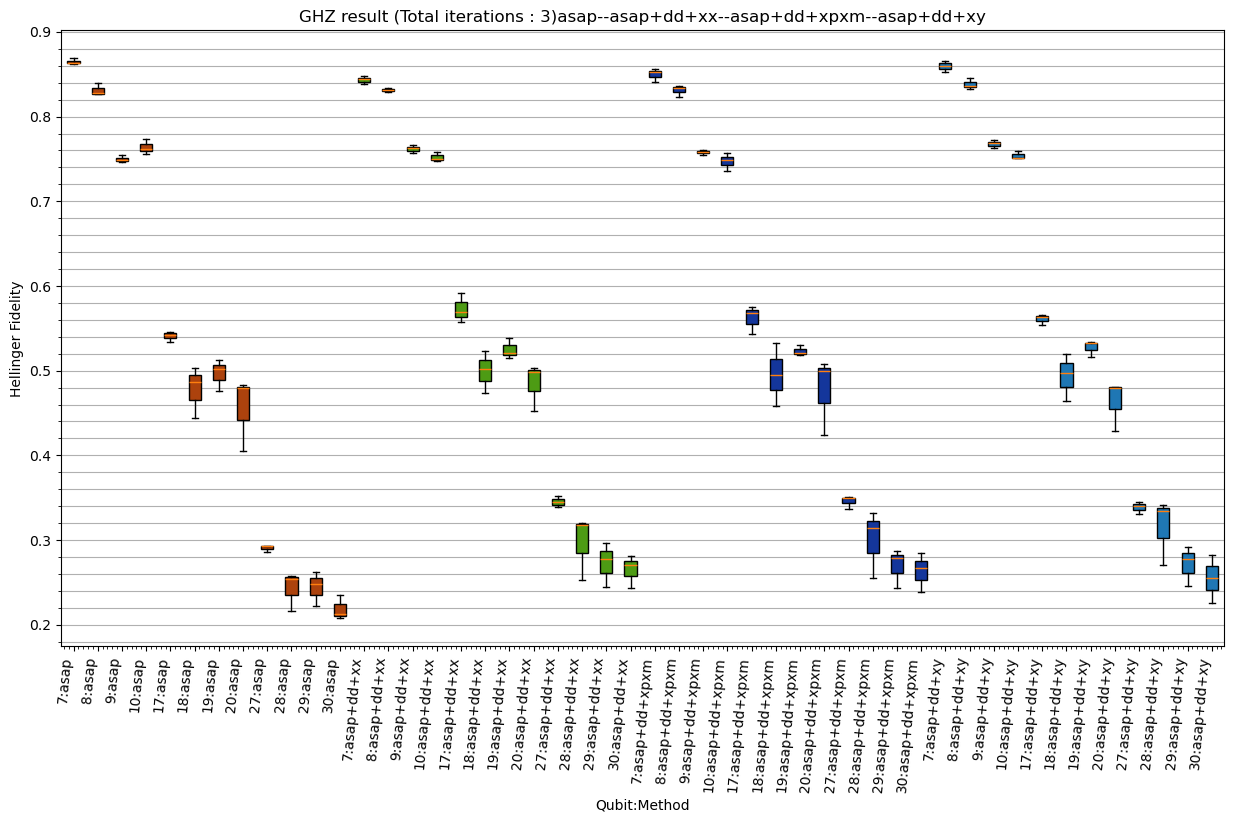

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plot_methods = ["asap", "asap+dd+xx", "asap+dd+xpxm", "asap+dd+xy"]
labels = [f"{qubit}:{method}" for method in plot_methods for qubit in qubits] 

data_for_label = []
for method in plot_methods:
    for qubit in qubits:
        data_for_label += [fidelity_dict[qubit][method]]


colors = ["#AC420D" for _ in qubits] + ["#4D9B14" for _ in qubits] + ["#14369B" for _ in qubits]

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title(f"GHZ result (Total iterations : {iterations})"+'--'.join(plot_methods))


bplot = ax.boxplot(data_for_label,
                   patch_artist=True,  # fill with color
                   meanline=True, meanprops=dict(color="#970B0B", linewidth=2), manage_ticks=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticklabels(labels, rotation=85, ha='right')

ax.minorticks_on()
ax.set_xlabel("Qubit:Method")
ax.grid(True, which = 'both' , axis="y")
plt.savefig("Fez_DD_GHZ_Sampler--"+'--'.join(plot_methods)+".png")
plt.show()

### ALAP performance

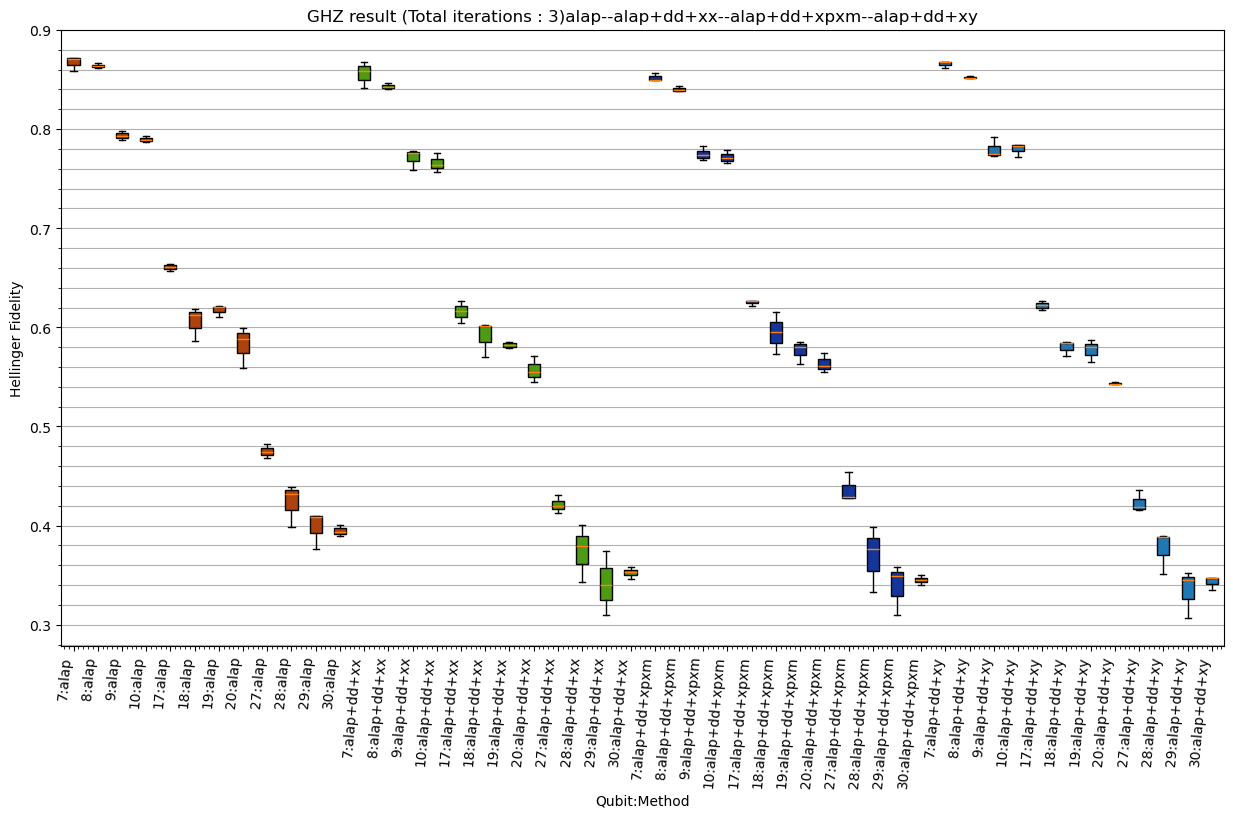

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plot_methods = ["alap", "alap+dd+xx", "alap+dd+xpxm", "alap+dd+xy"]
labels = [f"{qubit}:{method}" for method in plot_methods for qubit in qubits] 

data_for_label = []
for method in plot_methods:
    for qubit in qubits:
        data_for_label += [fidelity_dict[qubit][method]]


colors = ["#AC420D" for _ in qubits] + ["#4D9B14" for _ in qubits] + ["#14369B" for _ in qubits]

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title(f"GHZ result (Total iterations : {iterations})"+'--'.join(plot_methods))


bplot = ax.boxplot(data_for_label,
                   patch_artist=True,  # fill with color
                   meanline=True, meanprops=dict(color="#970B0B", linewidth=2), manage_ticks=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xticklabels(labels, rotation=85, ha='right')

ax.minorticks_on()
ax.set_xlabel("Qubit:Method")
ax.grid(True, which = 'both' , axis="y")
plt.savefig("Fez_DD_GHZ_Sampler--"+'--'.join(plot_methods)+".png")
plt.show()

### Average HF plots

In [18]:
import numpy as np
average_fidelity_dict = {qubit:{method:np.mean(fidelity_dict[qubit][method]) for method in valid_methods}  for qubit in qubits}

average_fidelity_dict

{7: {'none': 0.8731921866263065,
  'asap': 0.8647719198206056,
  'alap': 0.8672528293064307,
  'asap+dd+xx': 0.8434022649151931,
  'alap+dd+xx': 0.8559297855706426,
  'alap+dd+xpxm': 0.8519741879488402,
  'asap+dd+xpxm': 0.8498298796120799,
  'asap+dd+xy': 0.8593153726439442,
  'alap+dd+xy': 0.8655761472942288},
 8: {'none': 0.8581883391898929,
  'asap': 0.8312274019670975,
  'alap': 0.8638885543764986,
  'asap+dd+xx': 0.8309325050822275,
  'alap+dd+xx': 0.8432060560960704,
  'alap+dd+xpxm': 0.8404875460458343,
  'asap+dd+xpxm': 0.8312676484851677,
  'asap+dd+xy': 0.8385811139722638,
  'alap+dd+xy': 0.8524387348788682},
 9: {'none': 0.7894098019322243,
  'asap': 0.7496977496472682,
  'alap': 0.7934064671056641,
  'asap+dd+xx': 0.7619035470693419,
  'alap+dd+xx': 0.7707951637399498,
  'alap+dd+xpxm': 0.7752754579846245,
  'asap+dd+xpxm': 0.7579392745302814,
  'asap+dd+xy': 0.7677358642938411,
  'alap+dd+xy': 0.7797821656712672},
 10: {'none': 0.7796792981852118,
  'asap': 0.763856929954

In [19]:

plot_methods = ["none", "asap", "alap", "asap+dd+xx", "alap+dd+xx", "asap+dd+xpxm", "alap+dd+xpxm", "asap+dd+xy", "alap+dd+xy"]
qubit = 7
labels = [f"{qubit}:{method}" for method in plot_methods] 


data_for_label = []
for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

for i in range(len(labels)):
    print(labels[i], data_for_label[i])


7:none 0.8731921866263065
7:asap 0.8647719198206056
7:alap 0.8672528293064307
7:asap+dd+xx 0.8434022649151931
7:alap+dd+xx 0.8559297855706426
7:asap+dd+xpxm 0.8498298796120799
7:alap+dd+xpxm 0.8519741879488402
7:asap+dd+xy 0.8593153726439442
7:alap+dd+xy 0.8655761472942288


In [26]:


def get_all_average_hf_plot_data(qubit):
    plot_methods = ["none", "asap", "alap", "asap+dd+xx", "alap+dd+xx", "asap+dd+xpxm", "alap+dd+xpxm", "asap+dd+xy", "alap+dd+xy"]
    labels = plot_methods

    data_for_label = []
    for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

    return labels, data_for_label


def get_asap_average_hf_plot_data(qubit):
    plot_methods = ["none", "asap", "asap+dd+xx", "asap+dd+xpxm", "asap+dd+xy"]
    labels = plot_methods

    data_for_label = []
    for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

    return labels, data_for_label

def get_alap_average_hf_plot_data(qubit):
    plot_methods = ["none", "alap", "alap+dd+xx", "alap+dd+xpxm", "alap+dd+xy"]
    labels = plot_methods

    data_for_label = []
    for method in plot_methods:
        data_for_label += [average_fidelity_dict[qubit][method]]

    return labels, data_for_label


def plot_alap_hf_for_qubit(qubit, ax):

    labels, data = get_alap_average_hf_plot_data(qubit)


    ax.plot(range(len(data)), data, marker='o', linestyle='--', label=[qubit])

    ax.minorticks_on()
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    
    ax.grid(True)



def plot_asap_hf_for_qubit(qubit, ax):

    labels, data = get_asap_average_hf_plot_data(qubit)


    ax.plot(range(len(data)), data, marker='o', linestyle='--', label=[qubit])

    ax.minorticks_on()
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    
    ax.grid(True)



def plot_all_hf_for_qubit(qubit, ax):
    
    labels, data = get_all_average_hf_plot_data(qubit)


    ax.plot(range(len(data)), data, marker='o', linestyle='--', label=[qubit])

    ax.minorticks_on()
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()
    
    ax.grid(True)


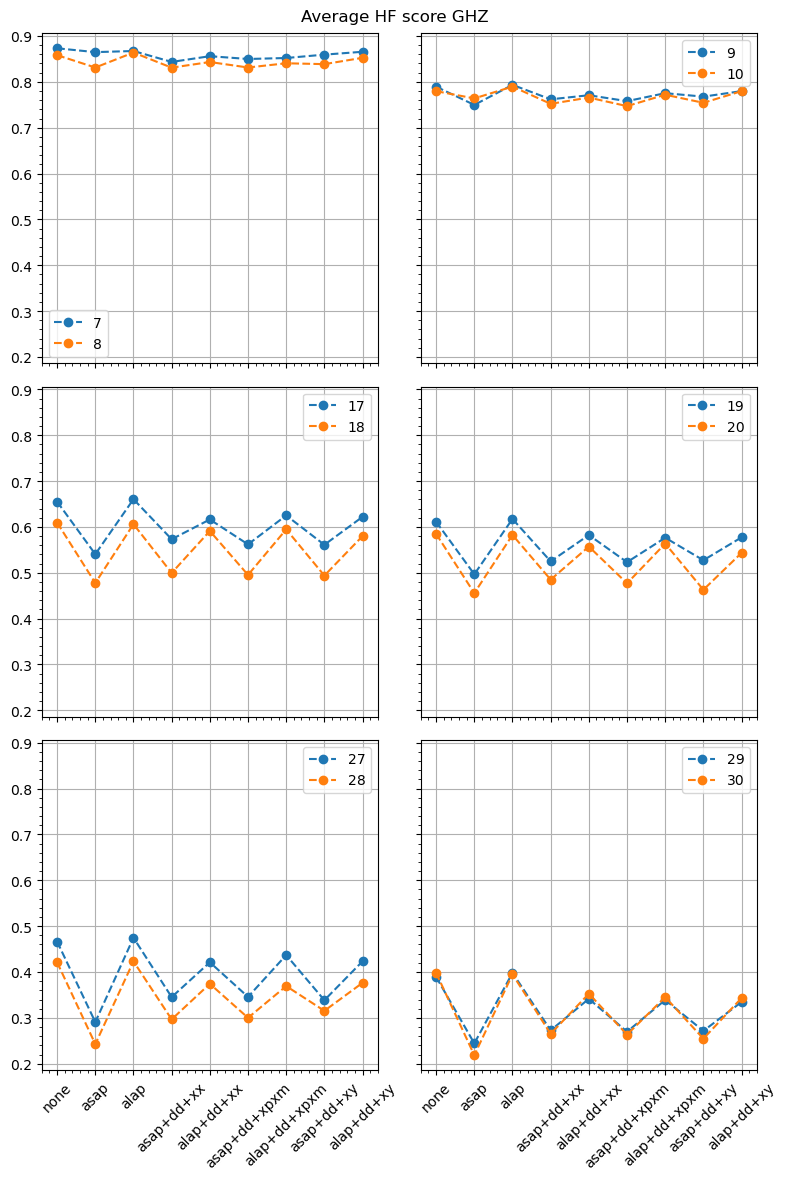

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=True, sharey=True)

plot_all_hf_for_qubit(7 , ax[0, 0])
plot_all_hf_for_qubit(8 , ax[0, 0])
plot_all_hf_for_qubit(9 , ax[0, 1])
plot_all_hf_for_qubit(10, ax[0, 1])
plot_all_hf_for_qubit(17, ax[1, 0])
plot_all_hf_for_qubit(18, ax[1, 0])
plot_all_hf_for_qubit(19, ax[1, 1])
plot_all_hf_for_qubit(20, ax[1, 1])
plot_all_hf_for_qubit(27, ax[2, 0])
plot_all_hf_for_qubit(28, ax[2, 0])
plot_all_hf_for_qubit(29, ax[2, 1])
plot_all_hf_for_qubit(30, ax[2, 1])


fig.suptitle("Average HF score GHZ")
fig.tight_layout()

fig.savefig("Fez_DD_Average_HF_score_GHZ.png")

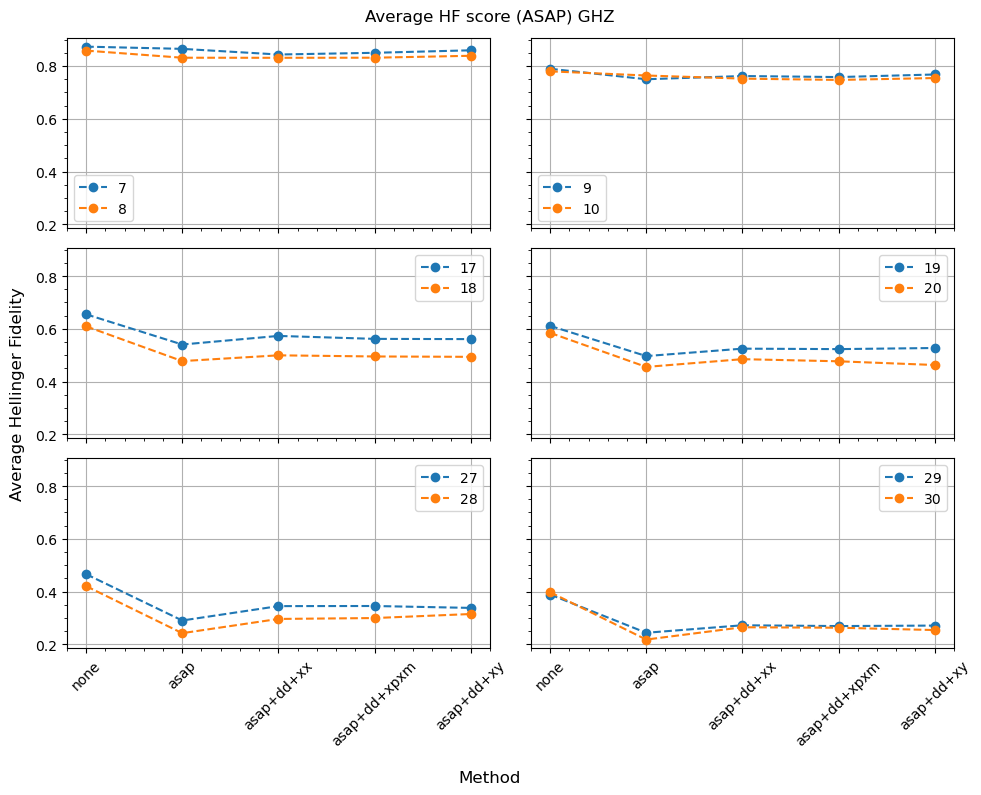

In [33]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=True, sharey=True)

plot_asap_hf_for_qubit(7 , ax[0, 0])
plot_asap_hf_for_qubit(8 , ax[0, 0])
plot_asap_hf_for_qubit(9 , ax[0, 1])
plot_asap_hf_for_qubit(10, ax[0, 1])
plot_asap_hf_for_qubit(17, ax[1, 0])
plot_asap_hf_for_qubit(18, ax[1, 0])
plot_asap_hf_for_qubit(19, ax[1, 1])
plot_asap_hf_for_qubit(20, ax[1, 1])
plot_asap_hf_for_qubit(27, ax[2, 0])
plot_asap_hf_for_qubit(28, ax[2, 0])
plot_asap_hf_for_qubit(29, ax[2, 1])
plot_asap_hf_for_qubit(30, ax[2, 1])

fig.supxlabel("Method")
fig.supylabel("Average Hellinger Fidelity")
fig.suptitle("Average HF score (ASAP) GHZ")
fig.tight_layout()

fig.savefig("Fez_DD_Average_HF_score(ASAP)_GHZ.png")

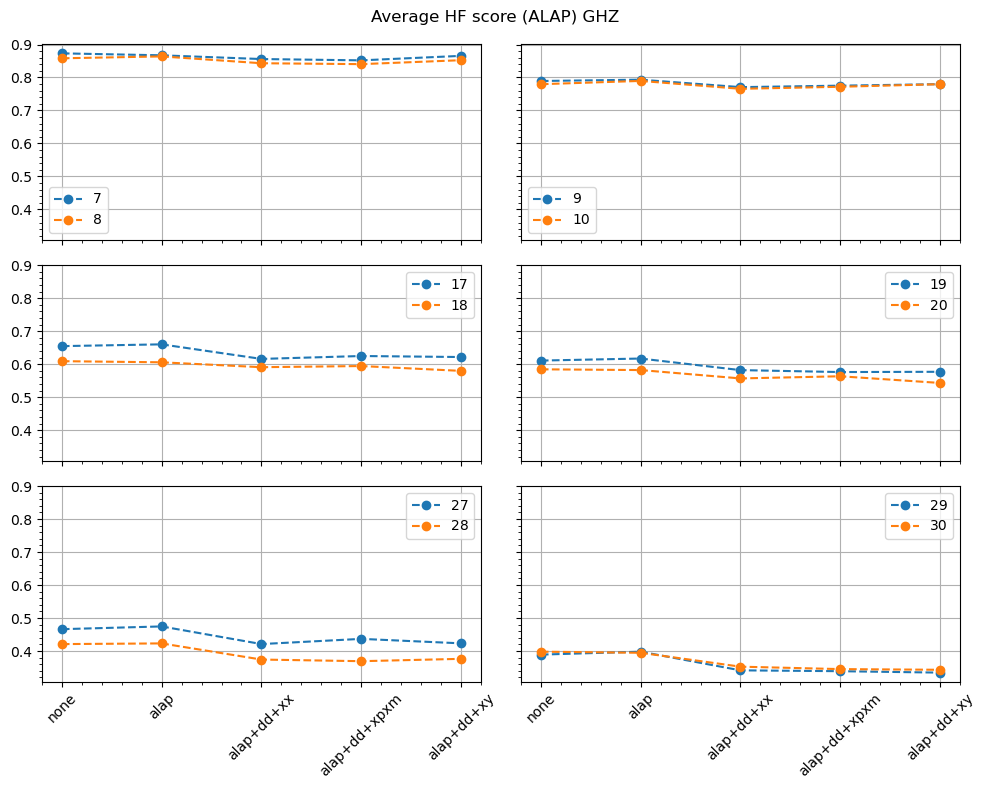

In [34]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=True, sharey=True)

plot_alap_hf_for_qubit(7 , ax[0, 0])
plot_alap_hf_for_qubit(8 , ax[0, 0])
plot_alap_hf_for_qubit(9 , ax[0, 1])
plot_alap_hf_for_qubit(10, ax[0, 1])
plot_alap_hf_for_qubit(17, ax[1, 0])
plot_alap_hf_for_qubit(18, ax[1, 0])
plot_alap_hf_for_qubit(19, ax[1, 1])
plot_alap_hf_for_qubit(20, ax[1, 1])
plot_alap_hf_for_qubit(27, ax[2, 0])
plot_alap_hf_for_qubit(28, ax[2, 0])
plot_alap_hf_for_qubit(29, ax[2, 1])
plot_alap_hf_for_qubit(30, ax[2, 1])


fig.suptitle("Average HF score (ALAP) GHZ")
fig.tight_layout()

fig.savefig("Fez_DD_Average_score(ALAP)_GHZ.png")

## Report

#### Circuit : GHZ

#### Qubits  : Low {7, 8, 9, 10}, Medium: {17, 18, 19, 20}, Large: {27, 28, 29, 30}

#### Types
- none  (Only opt 3 transpilation)
- opt 3 + ASAP
- opt 3 + ALAP
- opt 3 + ASAP + DD(xx)
- opt 3 + ALAP + DD(xx)
- opt 3 + ASAP + DD(xpxm)
- opt 3 + ALAP + DD(xpxm)
- opt 3 + ASAP + DD(xy)
- opt 3 + ALAP + DD(xy)

#### Iterations : 3 

### Results : 

#### Fig: Fez_DD_GHZ_Sampler--none--asap--alap.png
- Only opt 3 transpilation beats ASAP but is comparable to ALAP.
- We can infer qiskit uses ALAP internally when no scheduling analysis pass (ALAP, ASAP) is used. 

#### Fig: Fez_DD_Average_HF_score_GHZ.png
- Fidelity decreases as number of qubits increases.
 This is expected as for GHZ circuit the idle times increase with increasing qubits. 
- On an average "none" approx equal to "alap" and better than "asap". 

#### Fig: Fez_DD_Average_HF_score_GHZ_ASAP.png
- DD improves fidelity on average for asap scheduling
- All pulses (xx, xpxm, xy) show similar performance

#### Fig: Fez_DD_Average_HF_score_GHZ_ALAP.png
- DD does not improve fidelity


#### Other Comments:
- With ASAP we find improvement in fidelity with DD. 
- ALAP gives better fidelity overall than ASAP. But minimal DD performance